In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import os

folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('with_comfort.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
       
        df['timestamp'] = pd.to_datetime(df['timestamps'])
        
        df.drop(columns=['timestamps'], inplace=True)
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)

In [2]:
from dataclasses import dataclass
from typing import List, Tuple, Optional, Iterable
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
from sklearn.metrics import mean_absolute_error, r2_score
try:
    from sklearn.metrics import root_mean_squared_error
    _HAS_RMSE = True
except Exception: # older scikit-learn
    from sklearn.metrics import mean_squared_error
    _HAS_RMSE = False

# Optional for RC baseline
try:
    import statsmodels.api as sm
except Exception:
    sm = None

def make_splits_by_is_test_or_date(
    df: pd.DataFrame,
    val_start_str: str = "2023-01-22",
    val_days: int = 14,
    test_days: int = 14,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
   
    # Ensure datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        if "timestamps" in df.columns:
            df = df.copy()
            df["timestamps"] = pd.to_datetime(df["timestamps"])
            df = df.set_index("timestamps")
        else:
            raise ValueError("DataFrame must have a DateTimeIndex or a 'timestamps' column.")

    # Define windows
    val_start = pd.Timestamp(val_start_str)
    val_end   = val_start + pd.Timedelta(days=val_days)
    test_start = val_end
    test_end   = test_start + pd.Timedelta(days=test_days)

    # Build masks (inclusive start, exclusive end)
    idx = np.arange(len(df))
    ts = df.index

    val_mask  = (ts >= val_start) & (ts < val_end)
    test_mask = (ts >= test_start) & (ts < test_end)

    # Ensure they are disjoint
    overlap = val_mask & test_mask
    if overlap.any():
        raise RuntimeError("Validation and test windows overlap; check the inputs.")

    train_mask = ~(val_mask | test_mask)

    train_idx = idx[train_mask]
    val_idx   = idx[val_mask]
    test_idx  = idx[test_mask]

    return train_idx, val_idx, test_idx

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}
Best CV MAE: 0.14916745059613845
[Validation] MAE:   0.085 °C
[Validation] RMSE:  0.118 °C
[Validation] R²:    0.974
[Validation] sMAPE: 0.43 %


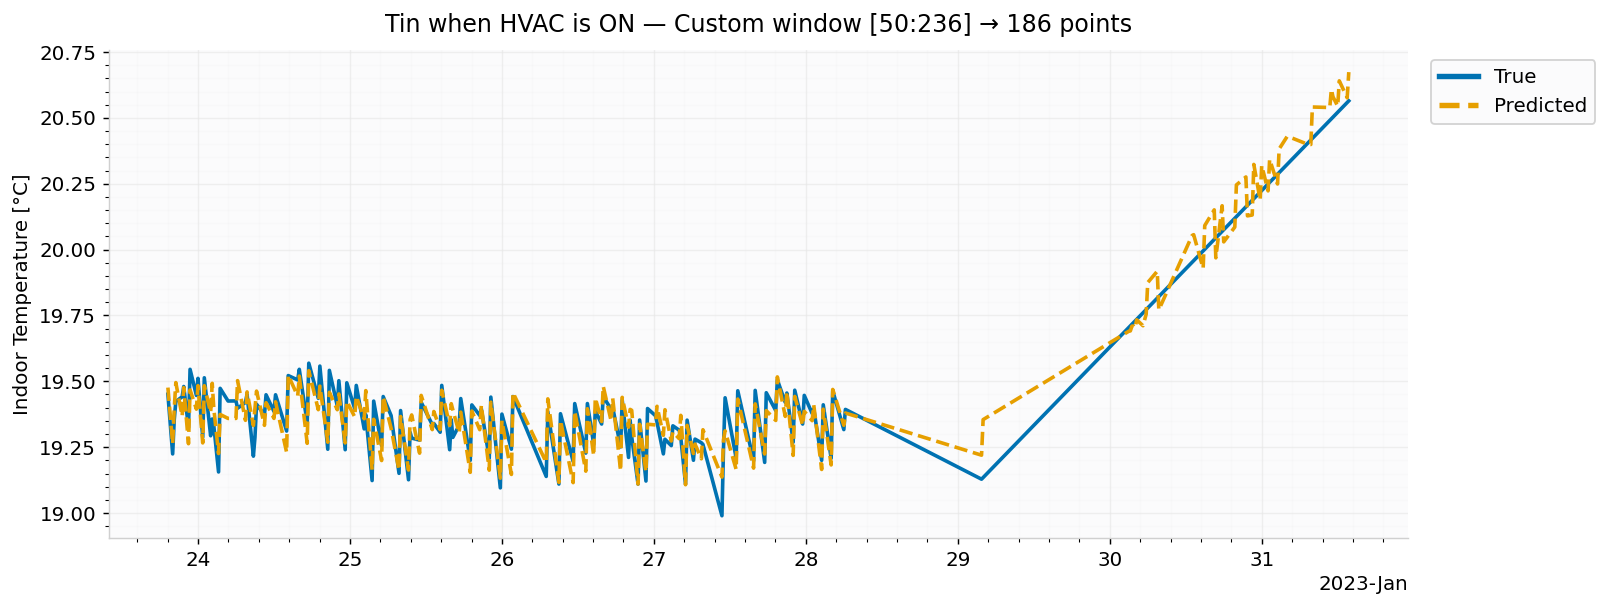

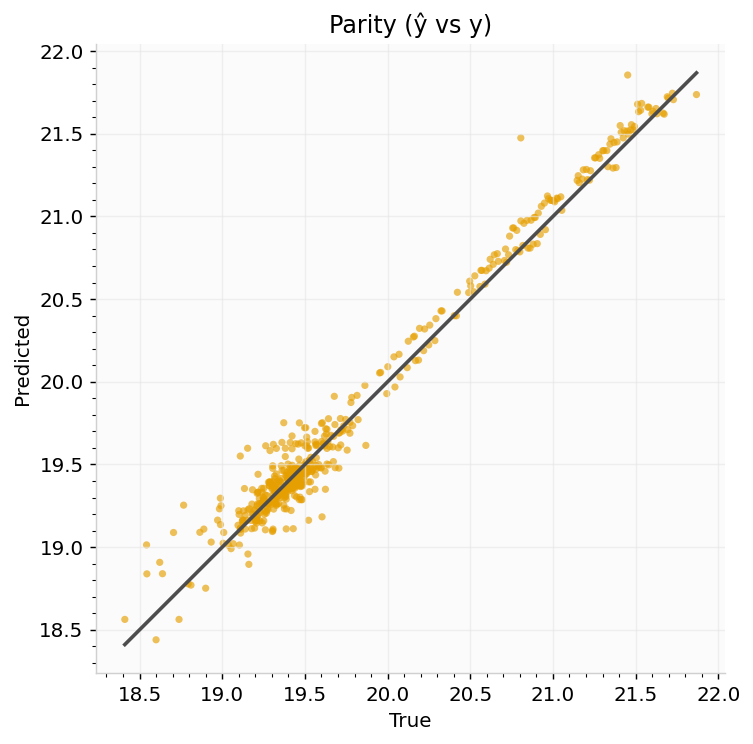

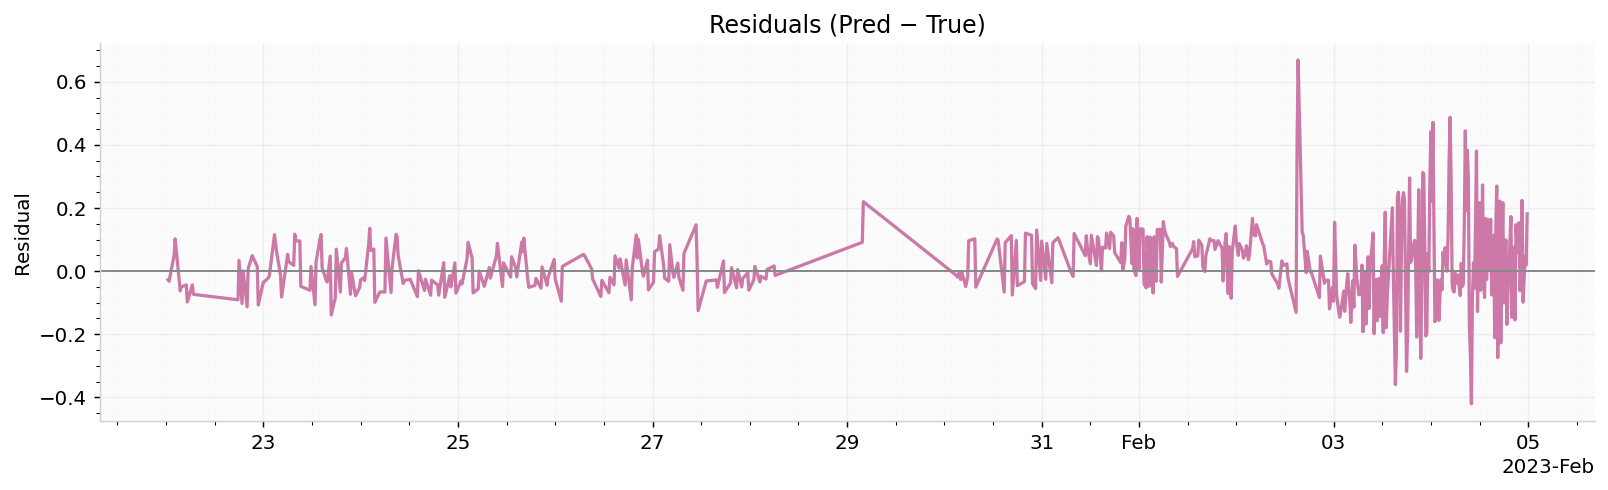

Test MAE: 0.059 °C
Test MAPE: 0.296 %
[df_0] Saved best RF model → models/df_0\best_model_rf.pkl


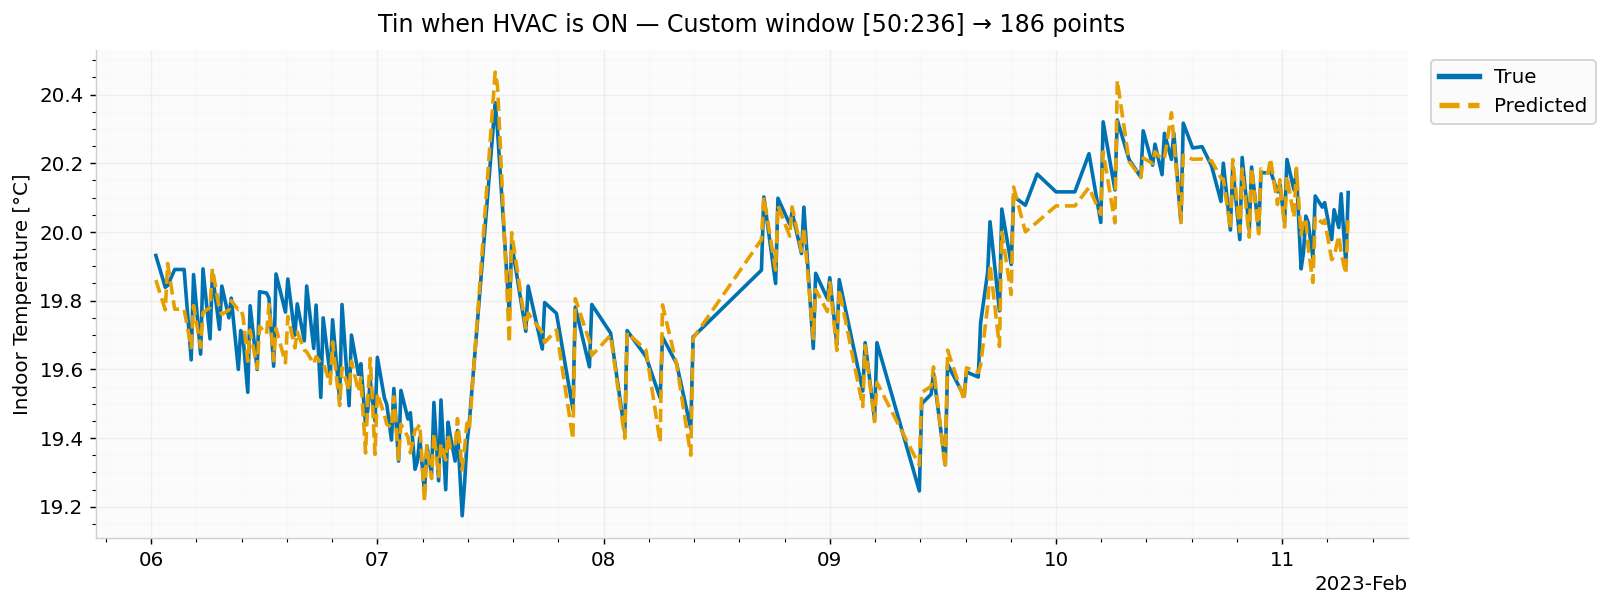

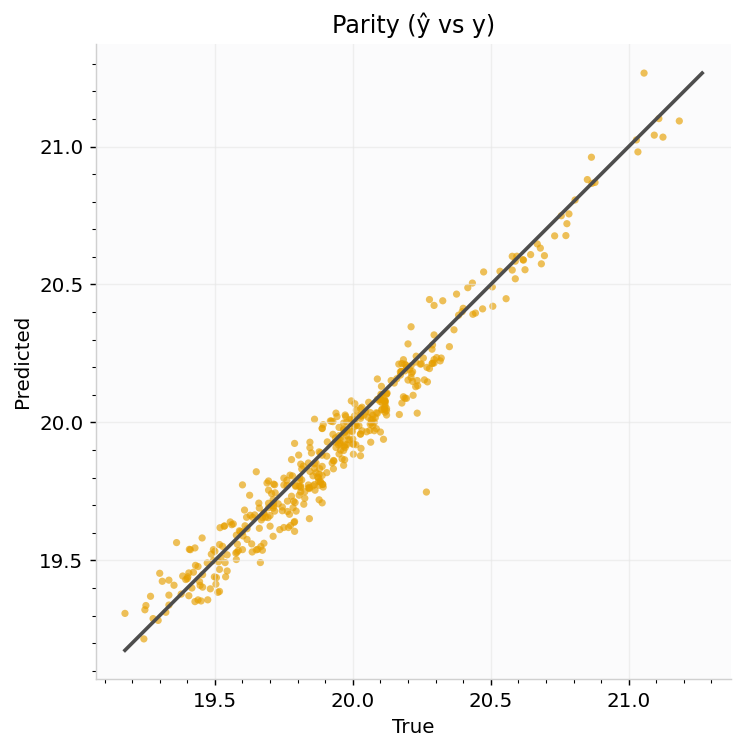

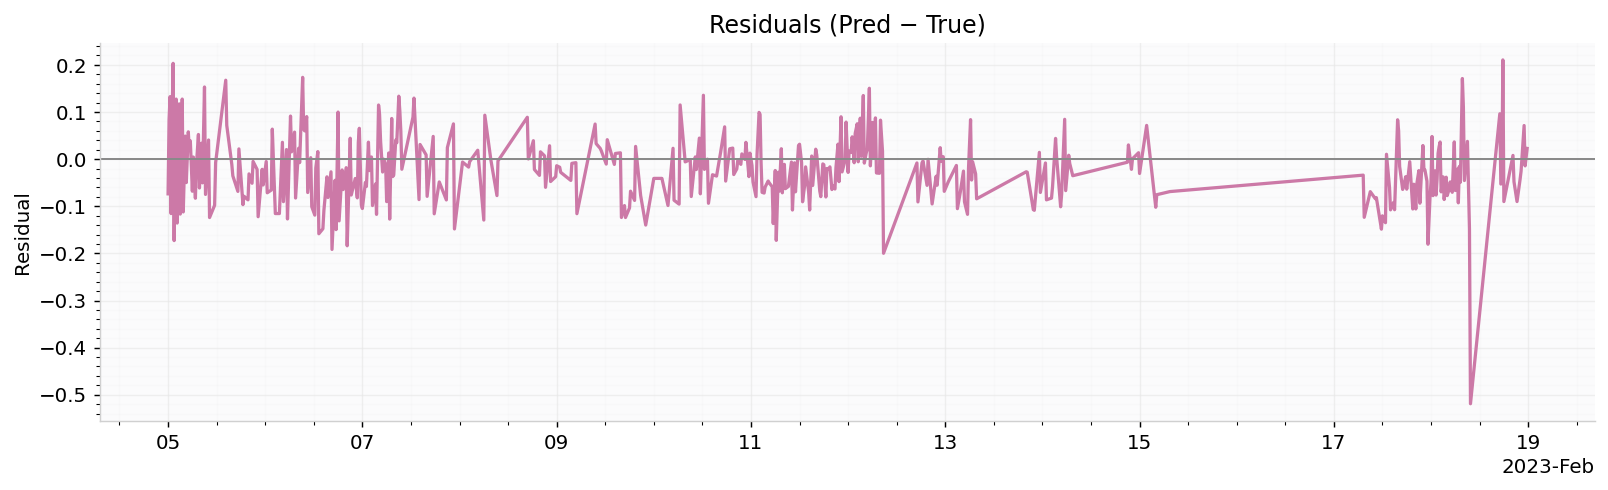

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 8, 'min_samples_leaf': 7, 'min_samples_split': 5, 'n_estimators': 160}
Best CV MAE: 0.15617858155731806
[Validation] MAE:   0.207 °C
[Validation] RMSE:  0.269 °C
[Validation] R²:    0.958
[Validation] sMAPE: 0.92 %


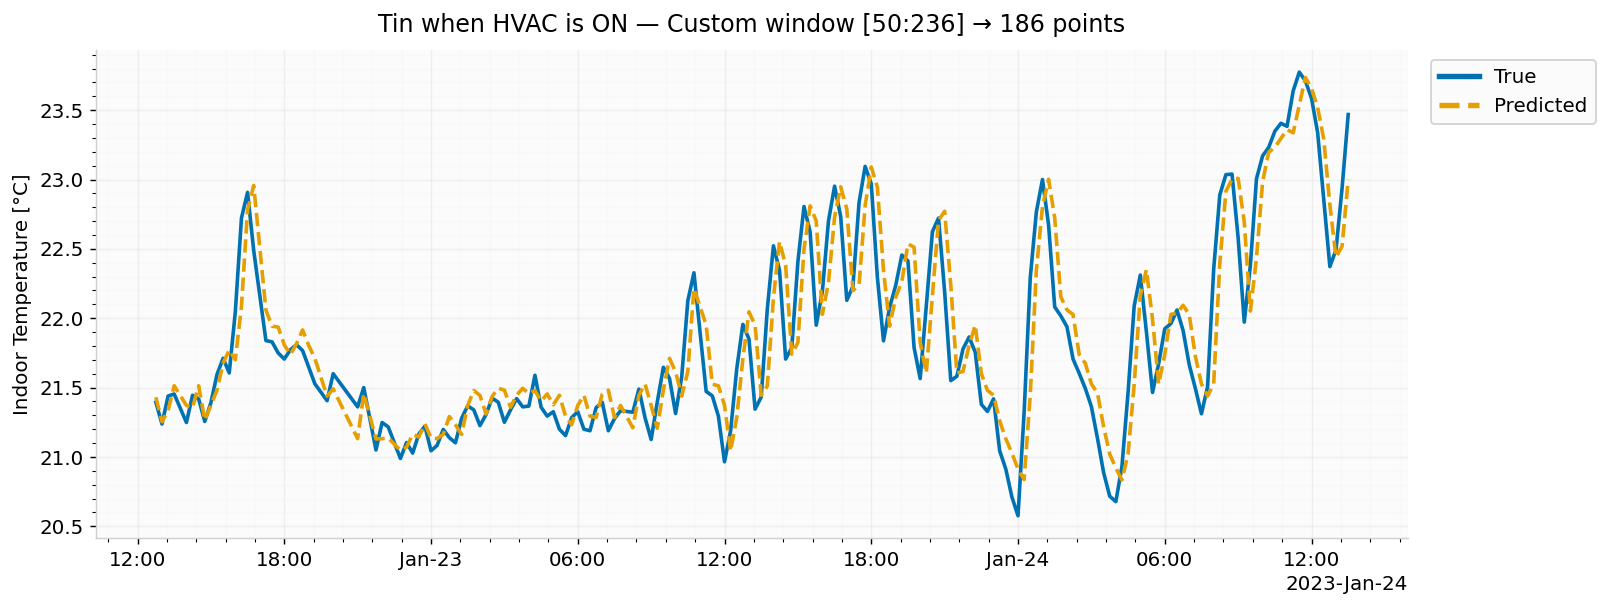

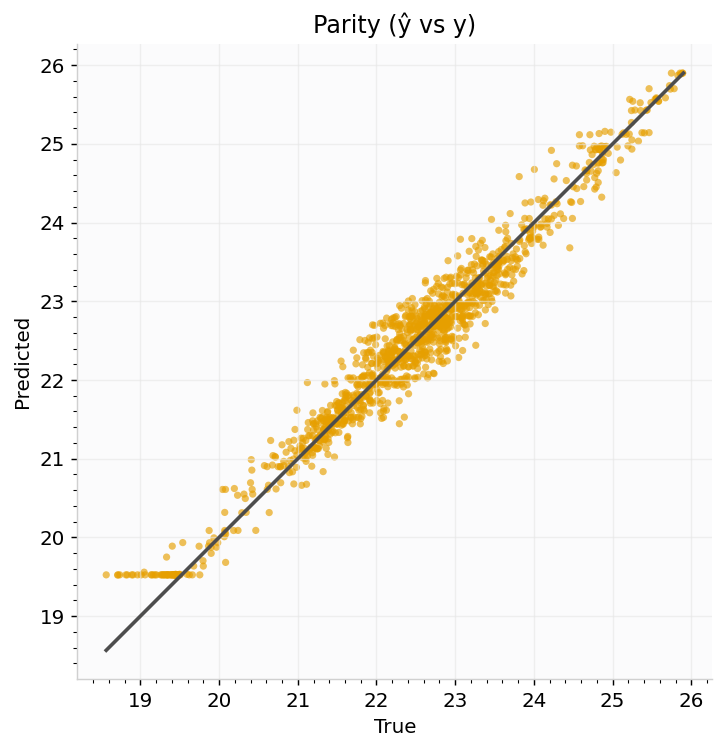

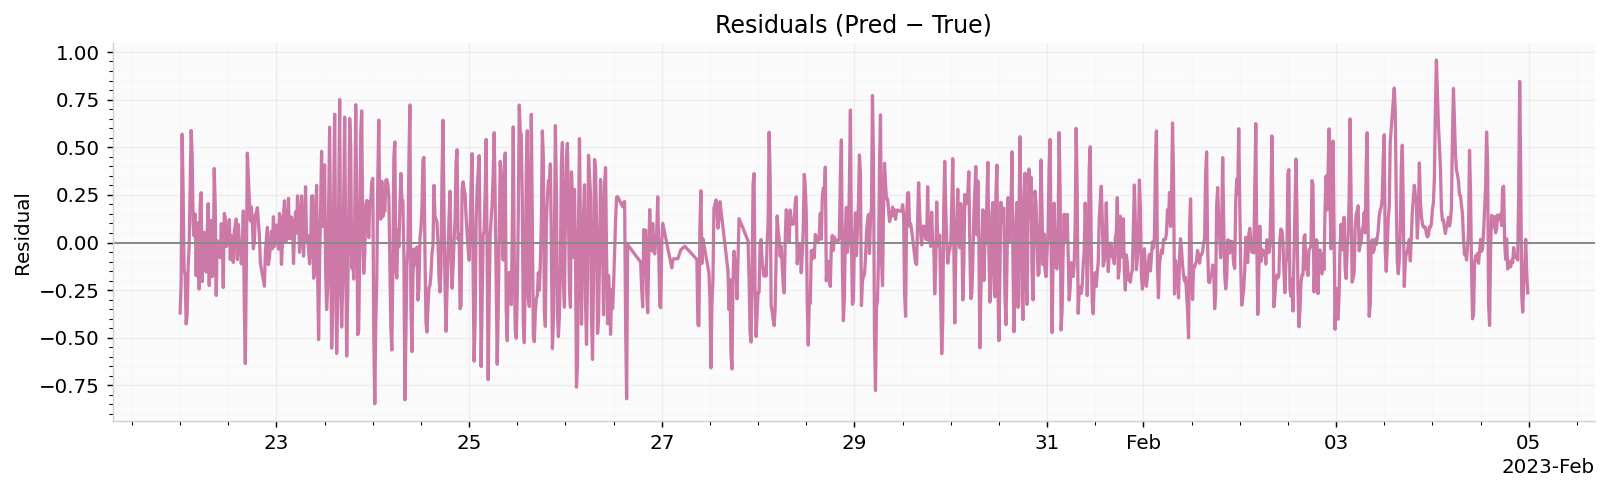

Test MAE: 0.165 °C
Test MAPE: 0.713 %
[df_1] Saved best RF model → models/df_1\best_model_rf.pkl


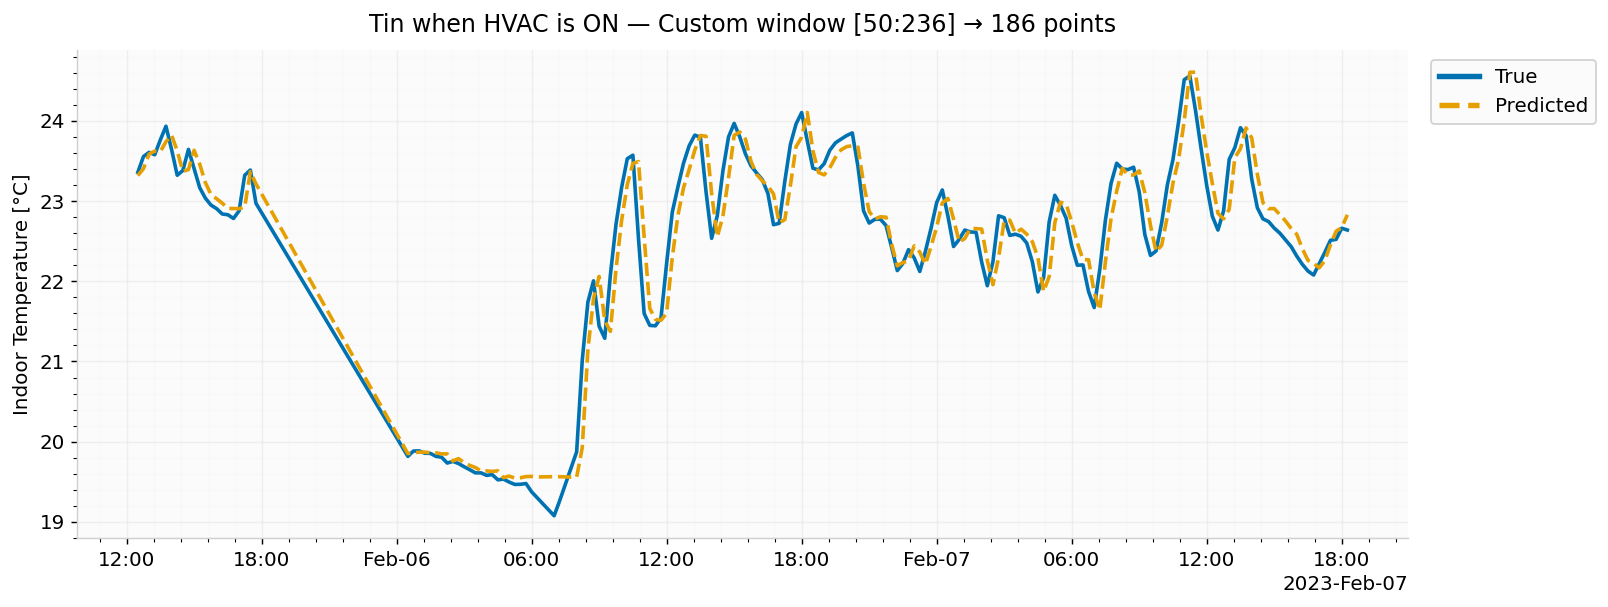

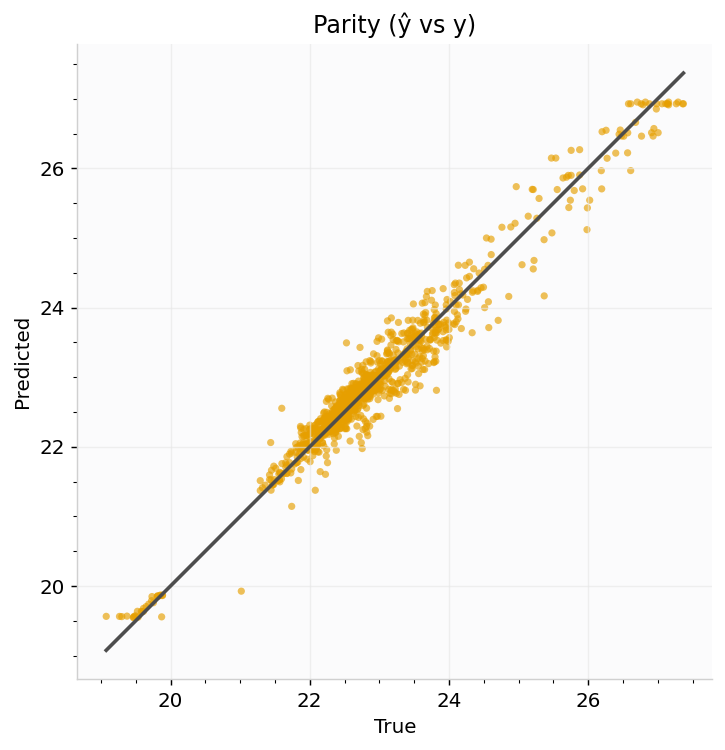

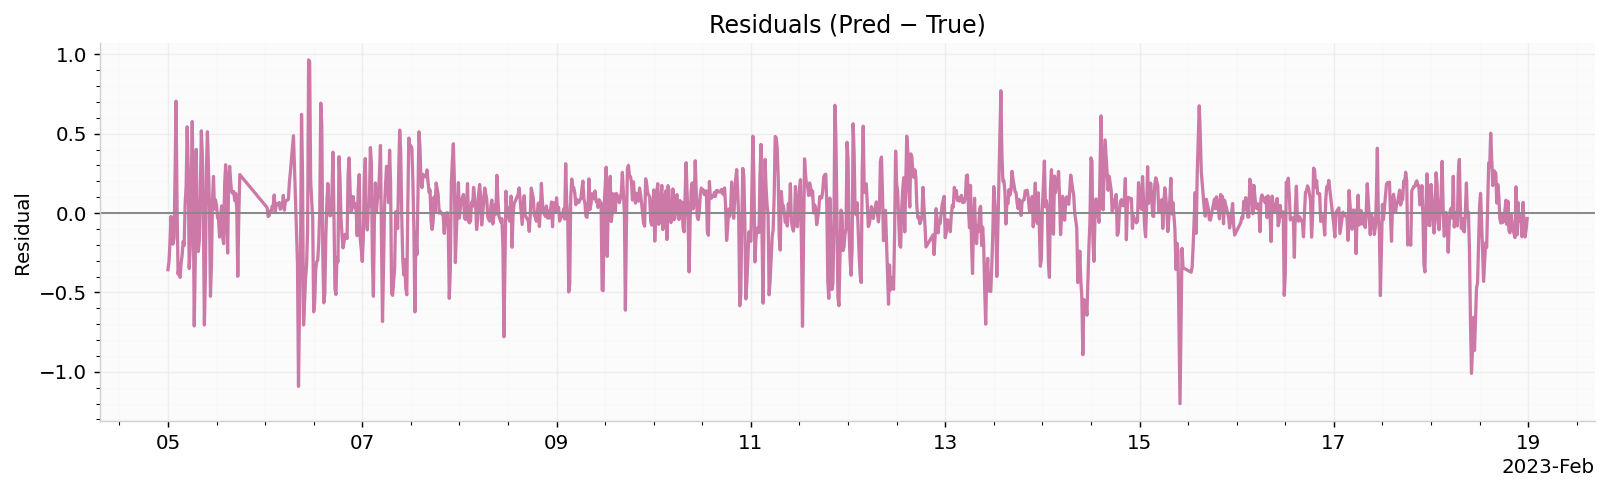

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV MAE: 0.10440984161528385
[Validation] MAE:   0.080 °C
[Validation] RMSE:  0.106 °C
[Validation] R²:    0.949
[Validation] sMAPE: 0.40 %


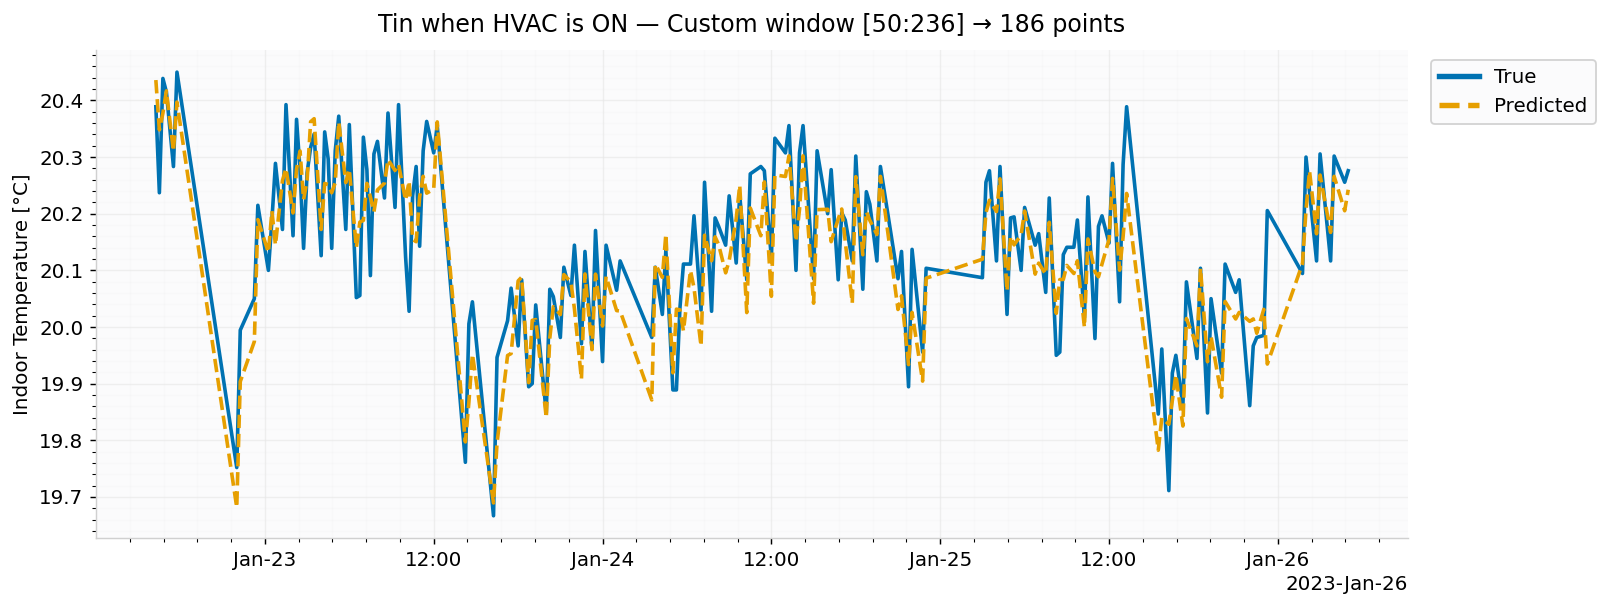

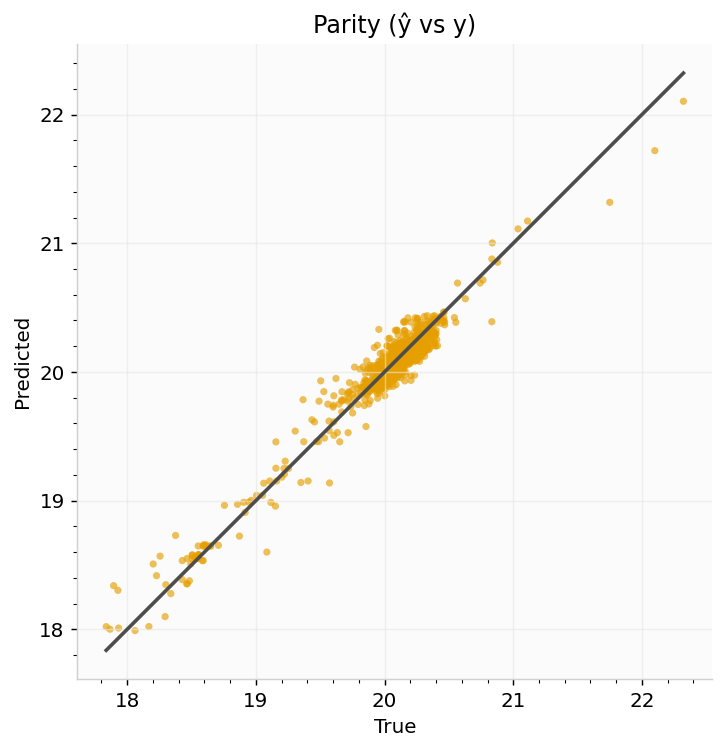

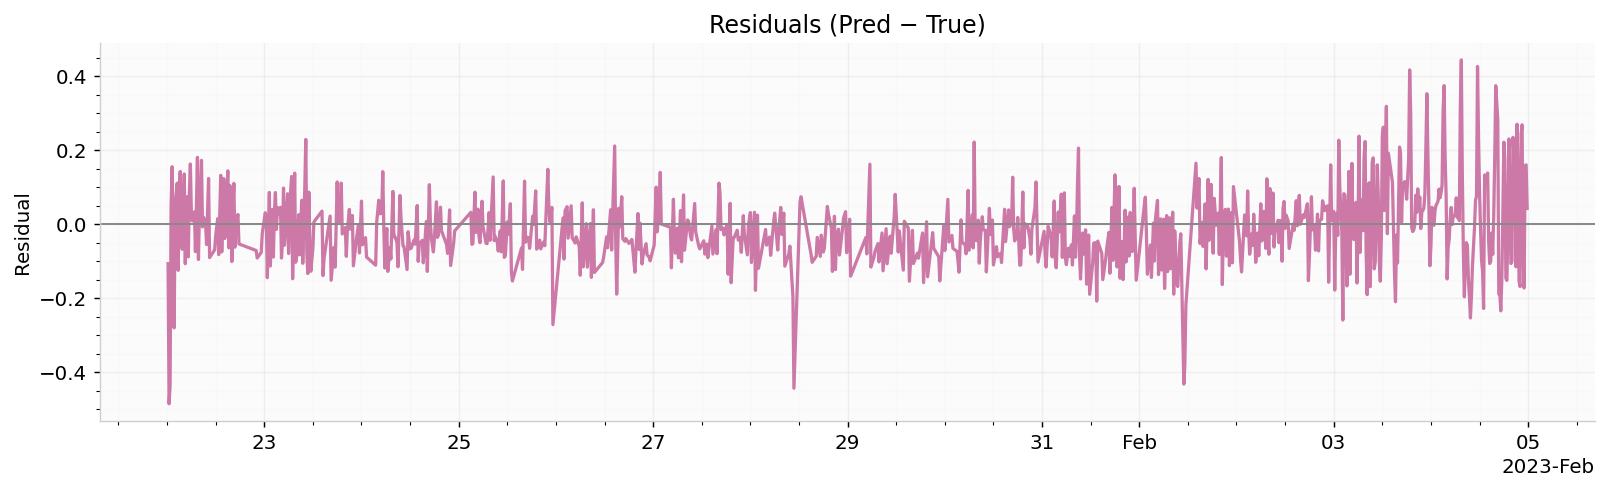

Test MAE: 0.079 °C
Test MAPE: 0.385 %
[df_2] Saved best RF model → models/df_2\best_model_rf.pkl


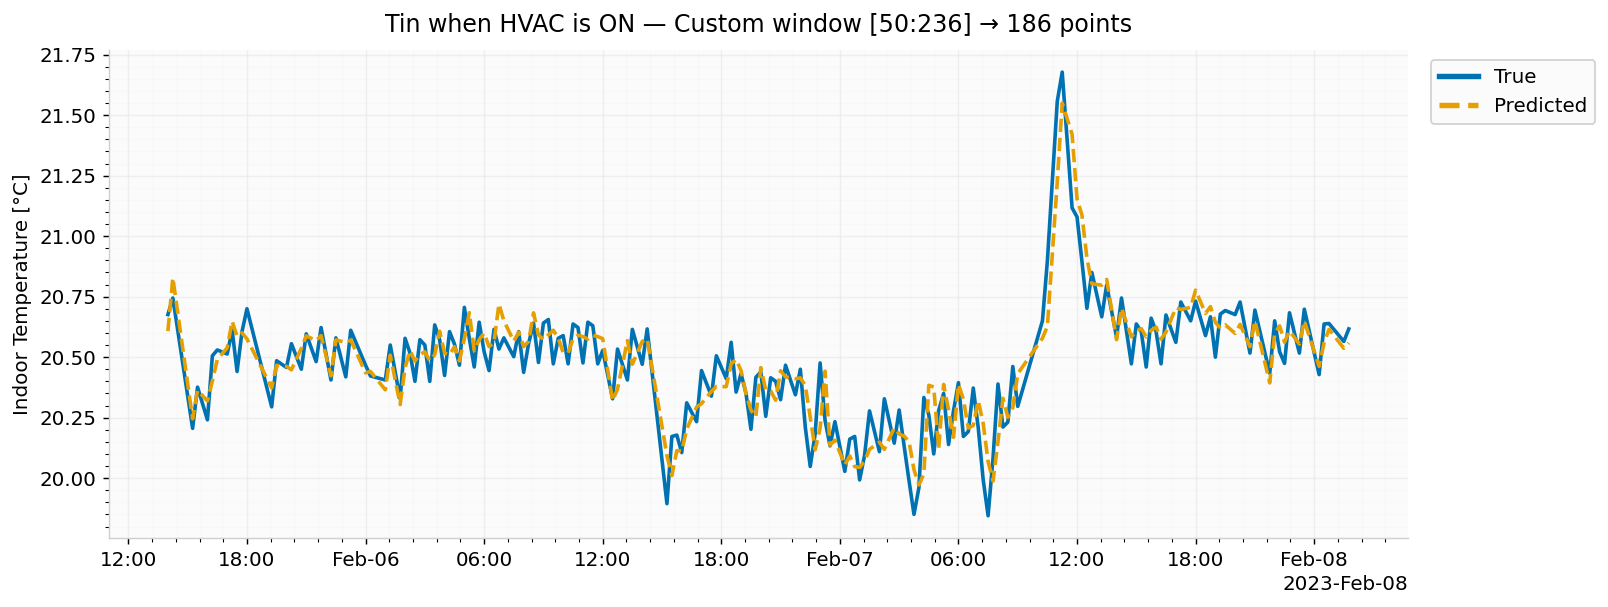

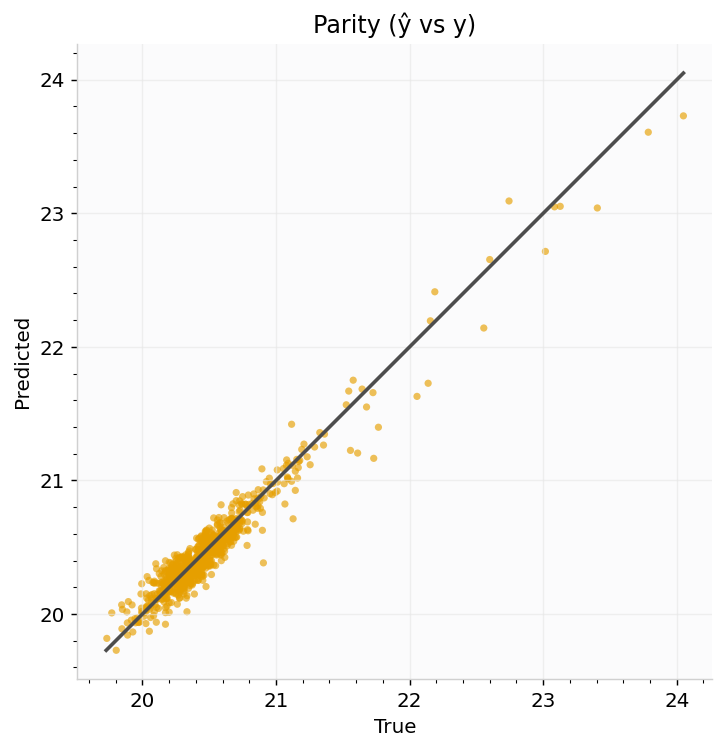

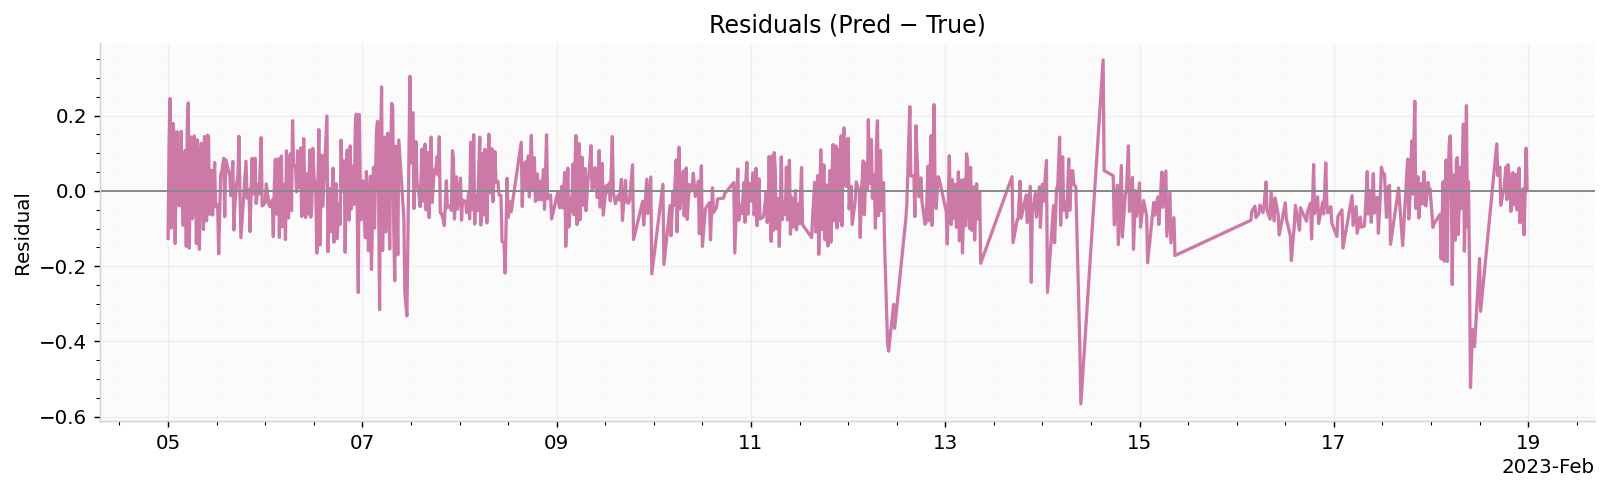

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 6, 'min_samples_leaf': 7, 'min_samples_split': 10, 'n_estimators': 200}
Best CV MAE: 0.14659572380397956
[Validation] MAE:   0.154 °C
[Validation] RMSE:  0.249 °C
[Validation] R²:    0.824
[Validation] sMAPE: 0.69 %


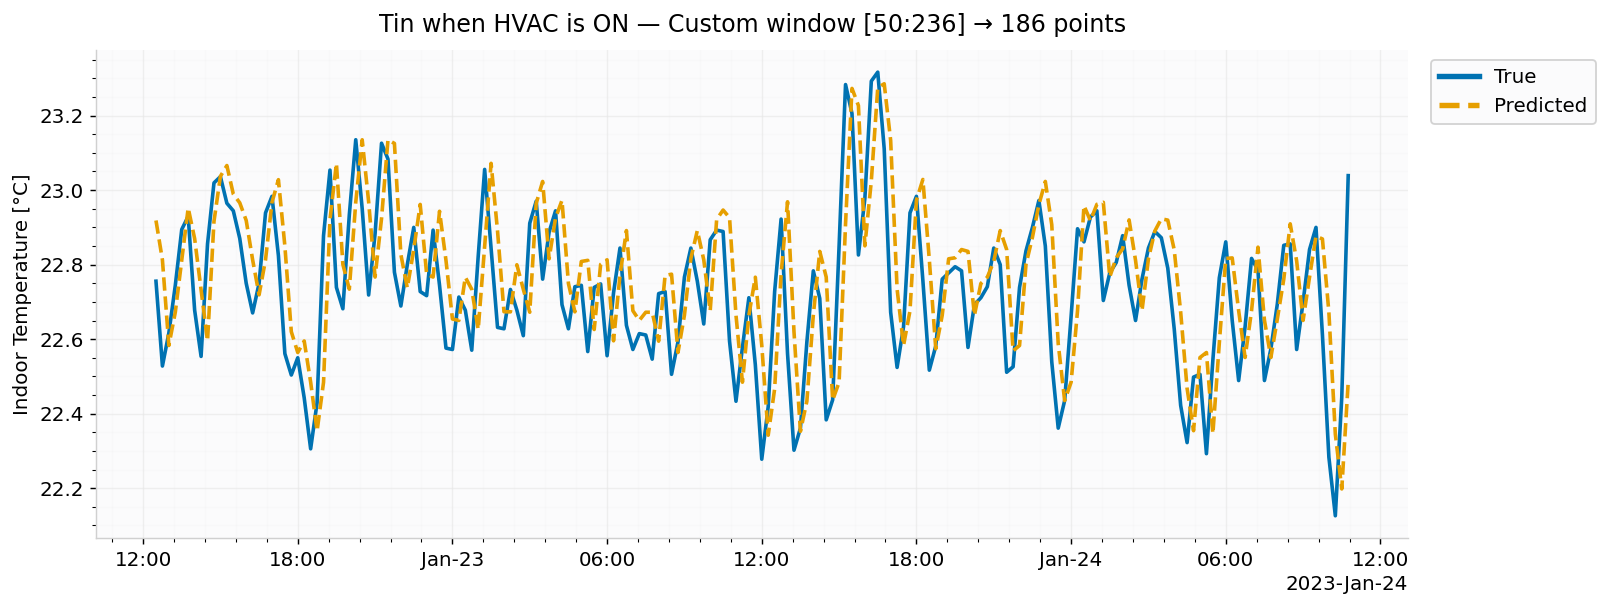

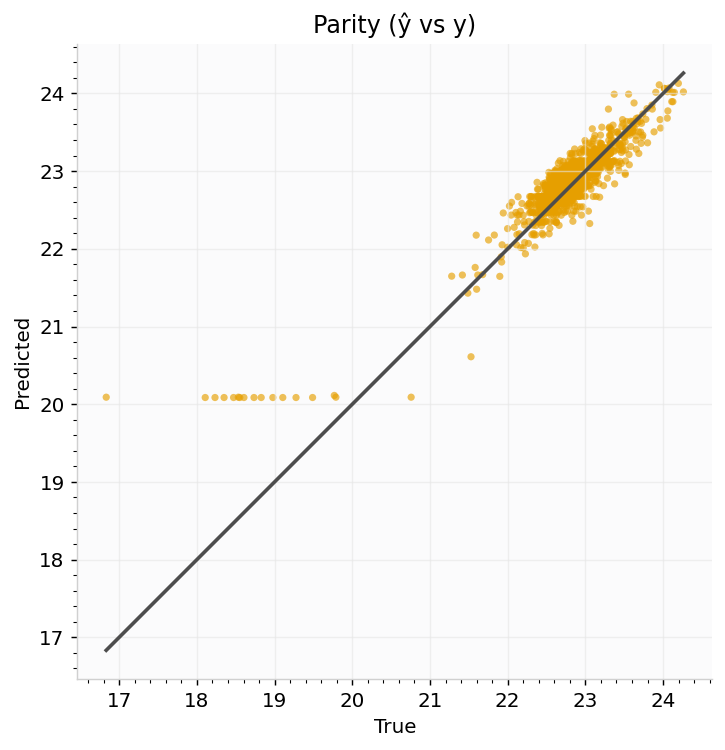

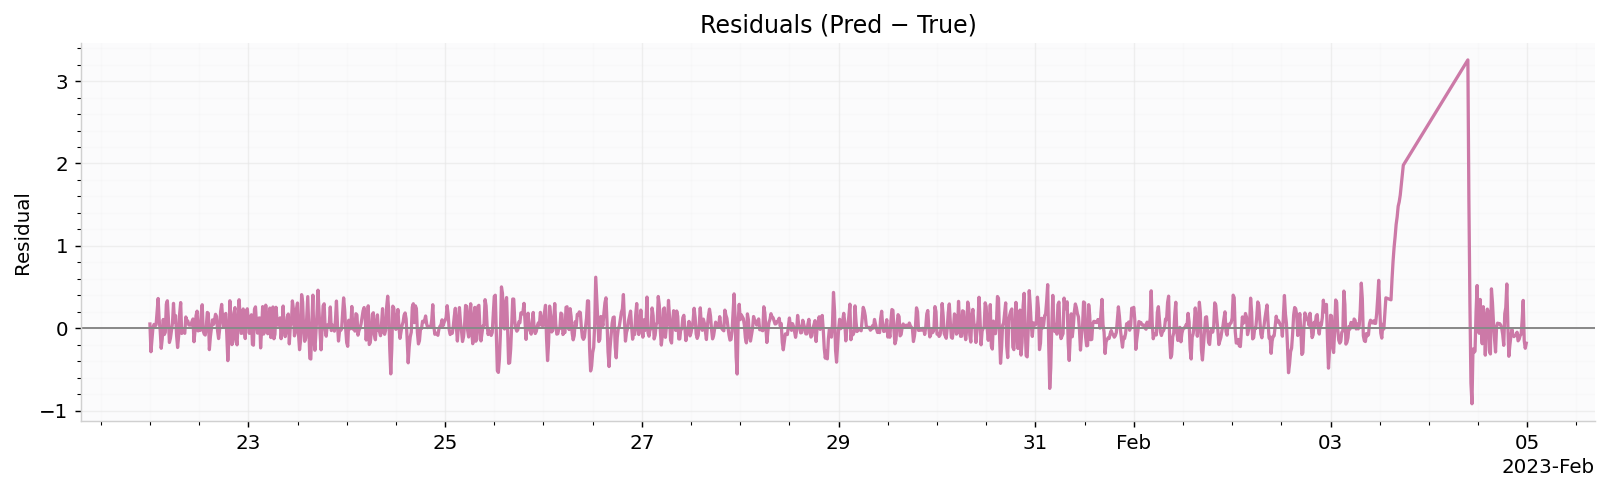

Test MAE: 0.127 °C
Test MAPE: 0.544 %
[df_3] Saved best RF model → models/df_3\best_model_rf.pkl


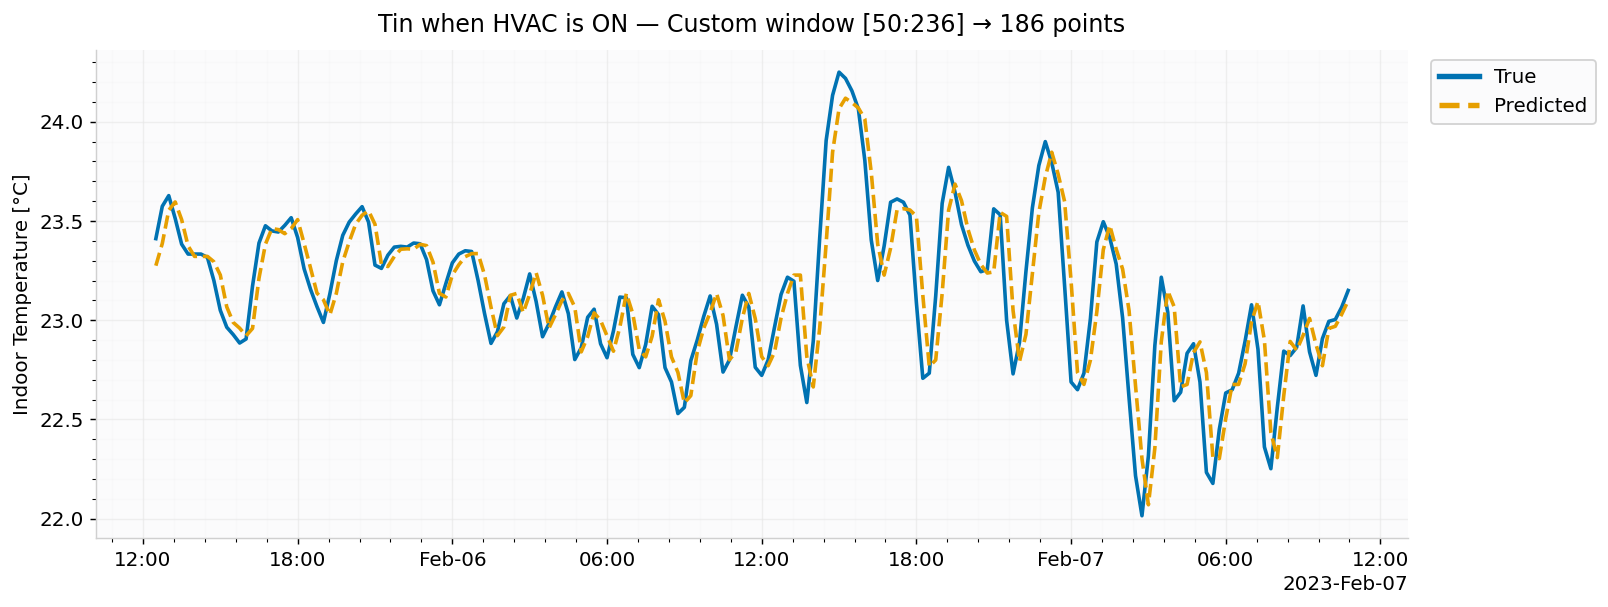

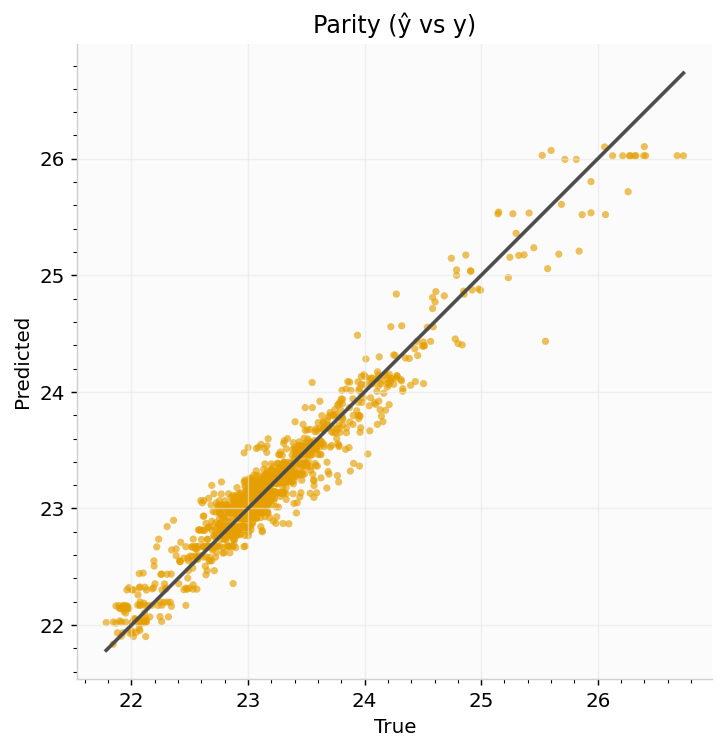

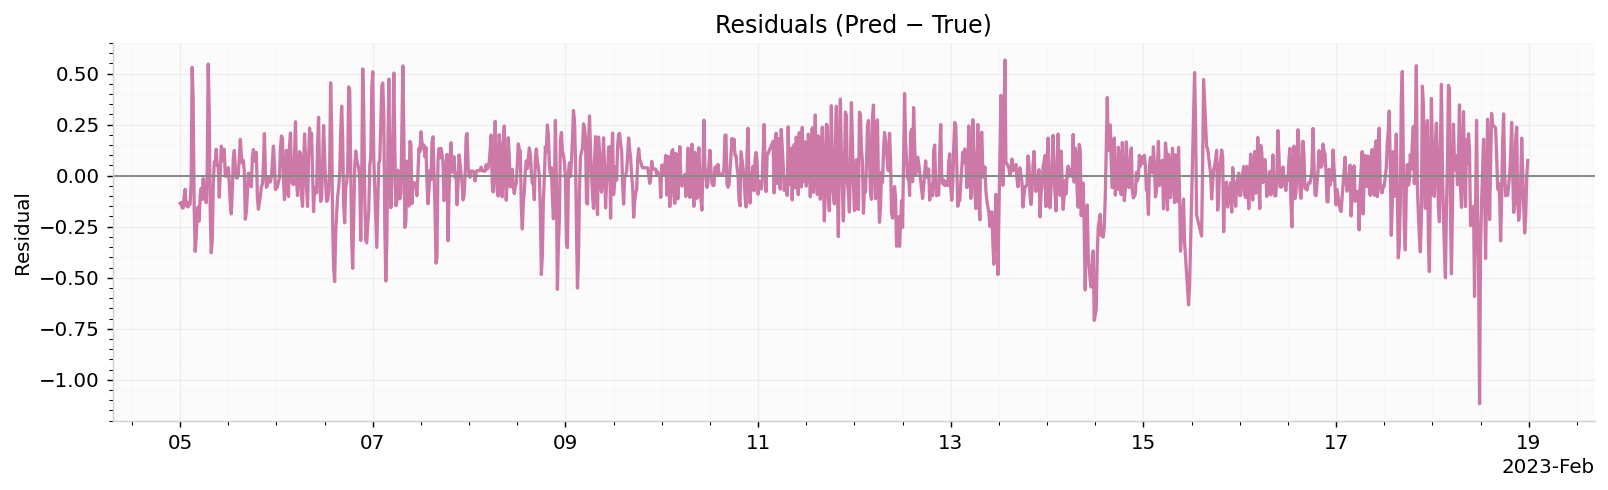

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 200}
Best CV MAE: 0.09195114955580305
[Validation] MAE:   0.300 °C
[Validation] RMSE:  0.488 °C
[Validation] R²:    0.875
[Validation] sMAPE: 1.58 %


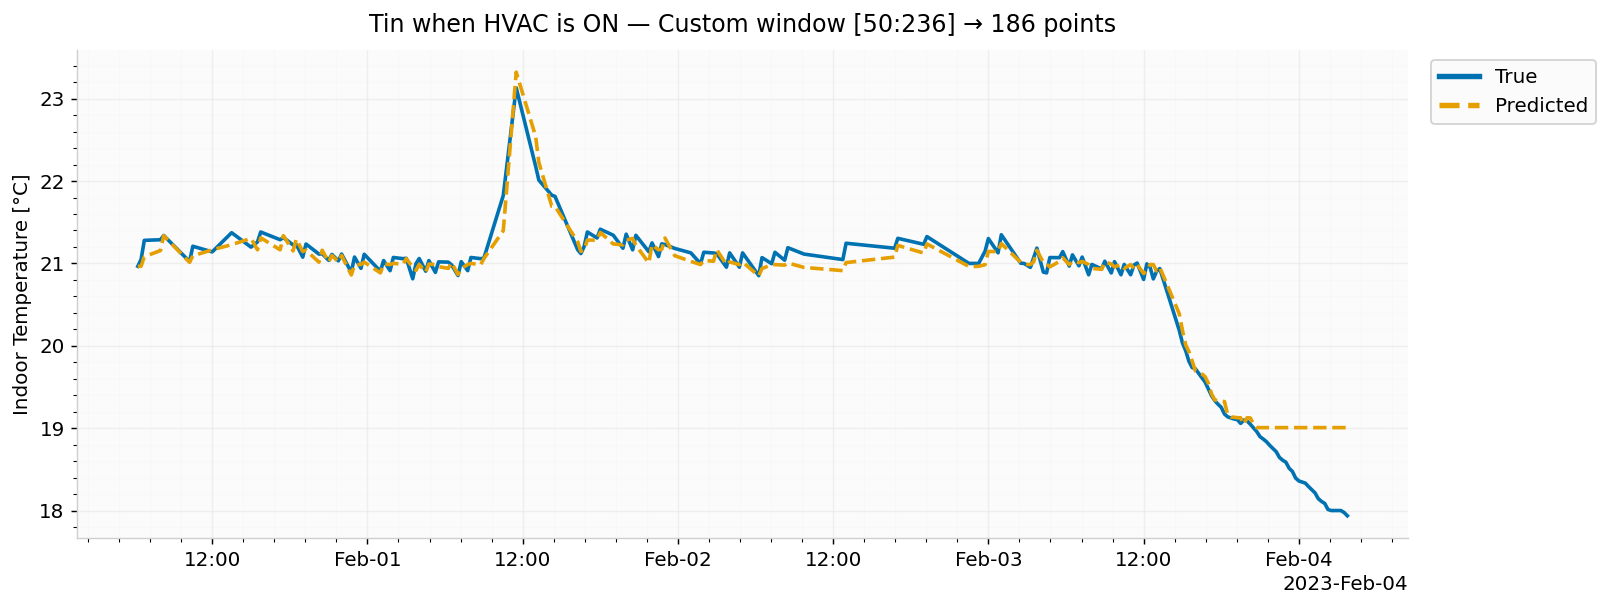

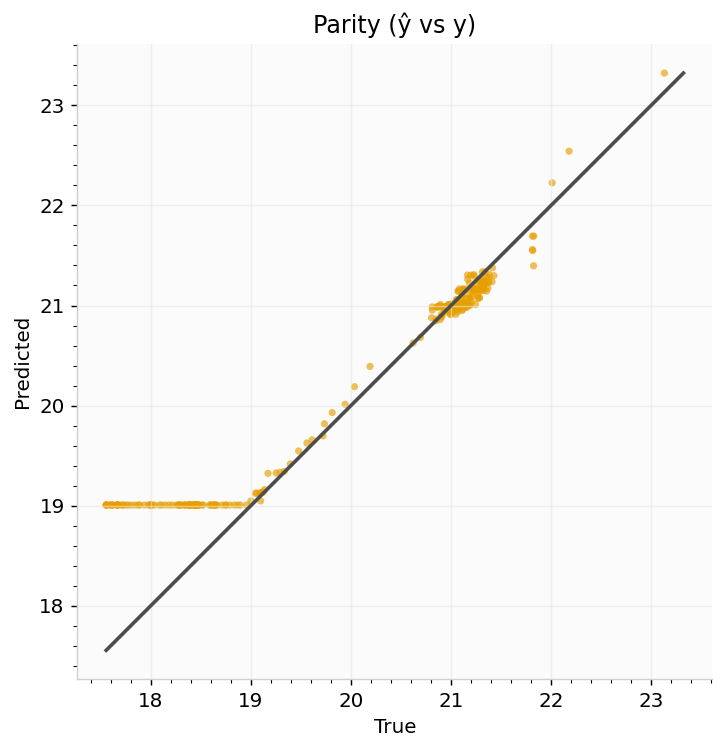

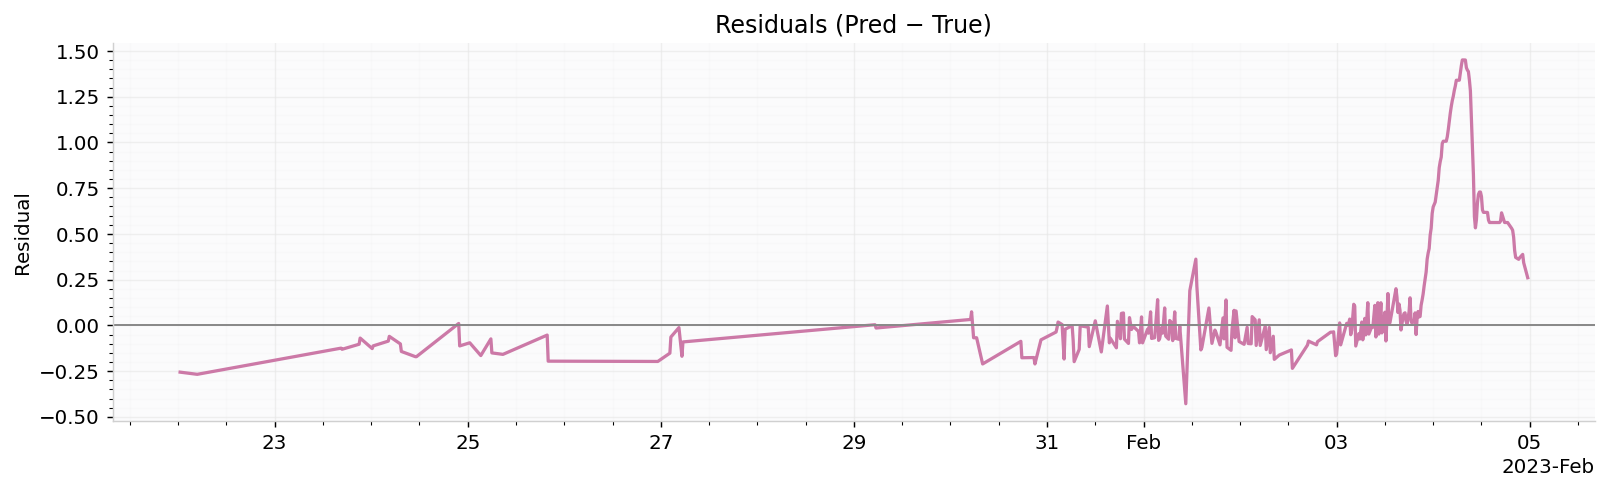

Test MAE: 0.022 °C
Test MAPE: 0.110 %
[df_4] Saved best RF model → models/df_4\best_model_rf.pkl


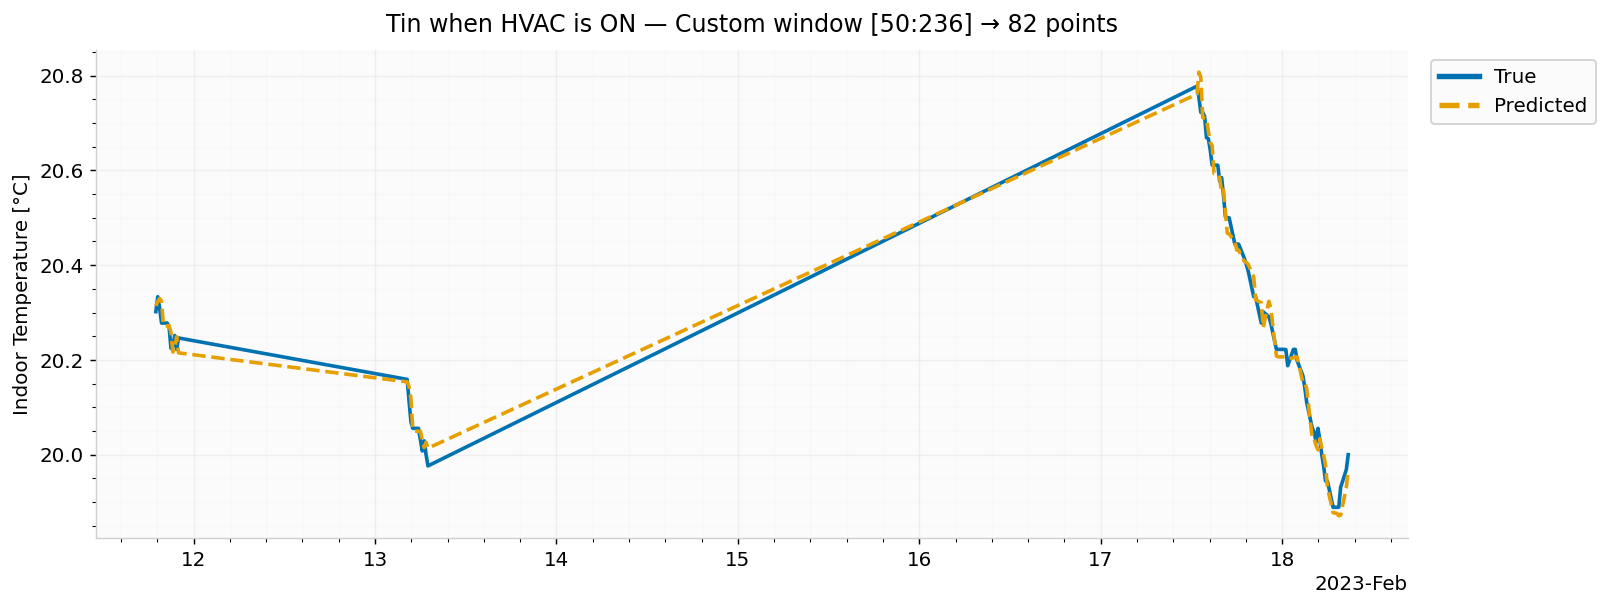

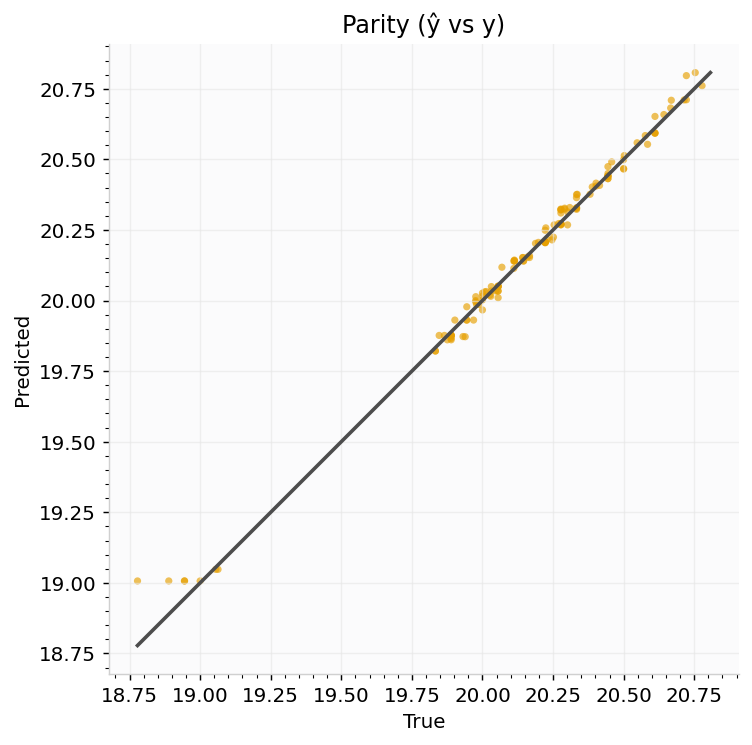

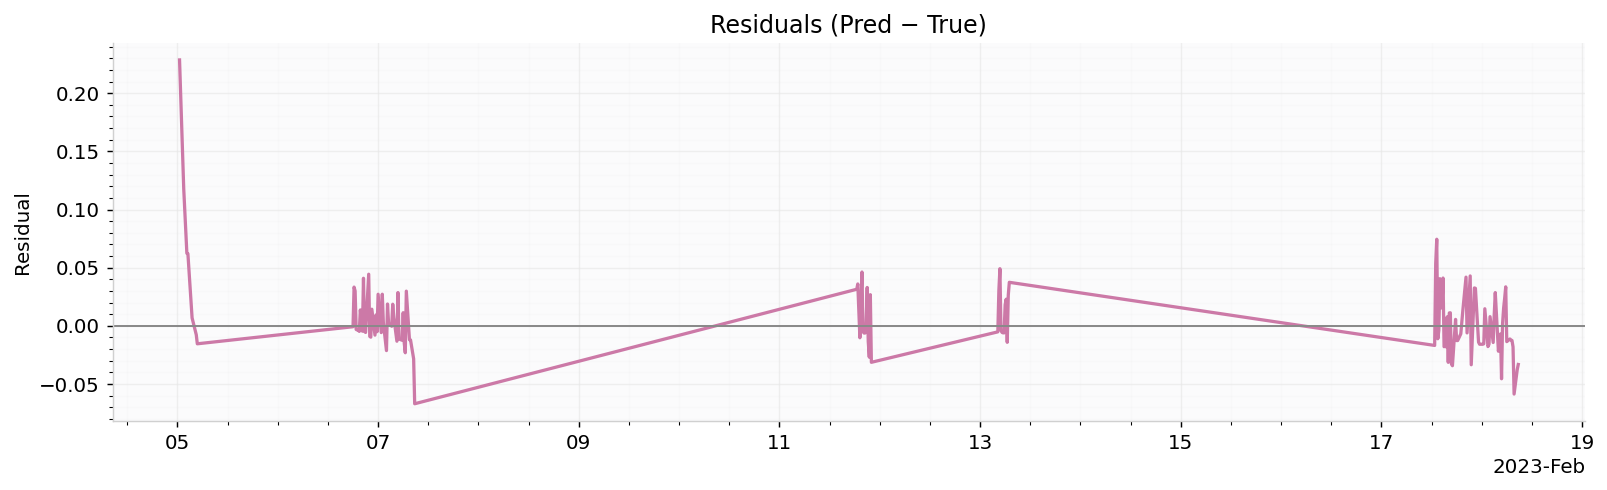

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}
Best CV MAE: 0.09611063201397528
[Validation] MAE:   0.098 °C
[Validation] RMSE:  0.130 °C
[Validation] R²:    0.869
[Validation] sMAPE: 0.49 %


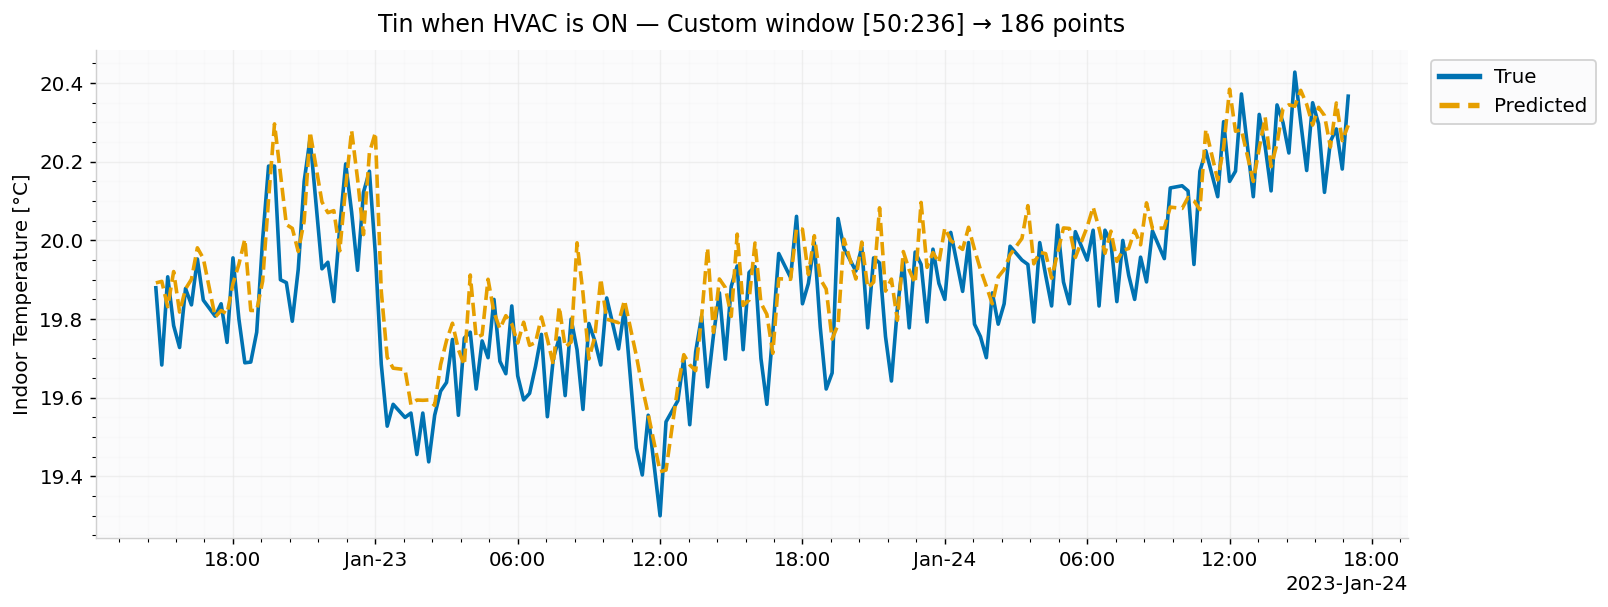

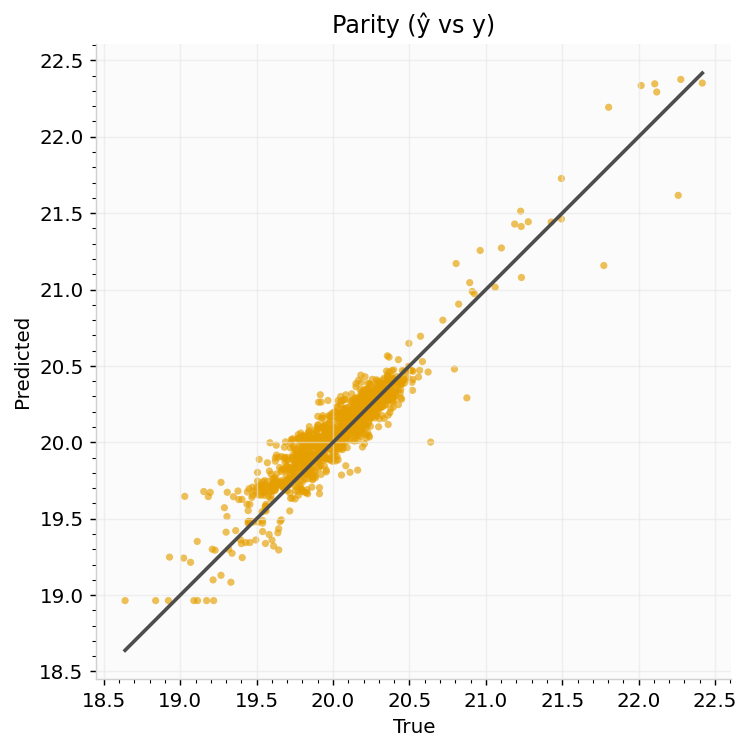

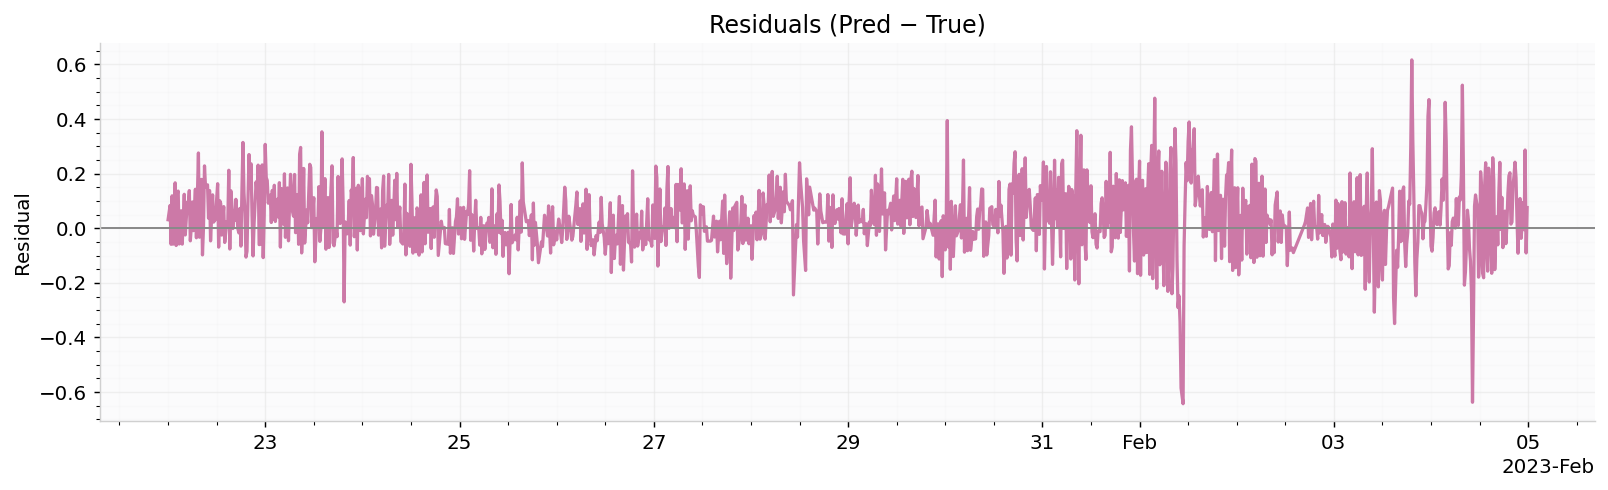

Test MAE: 0.058 °C
Test MAPE: 0.292 %
[df_5] Saved best RF model → models/df_5\best_model_rf.pkl


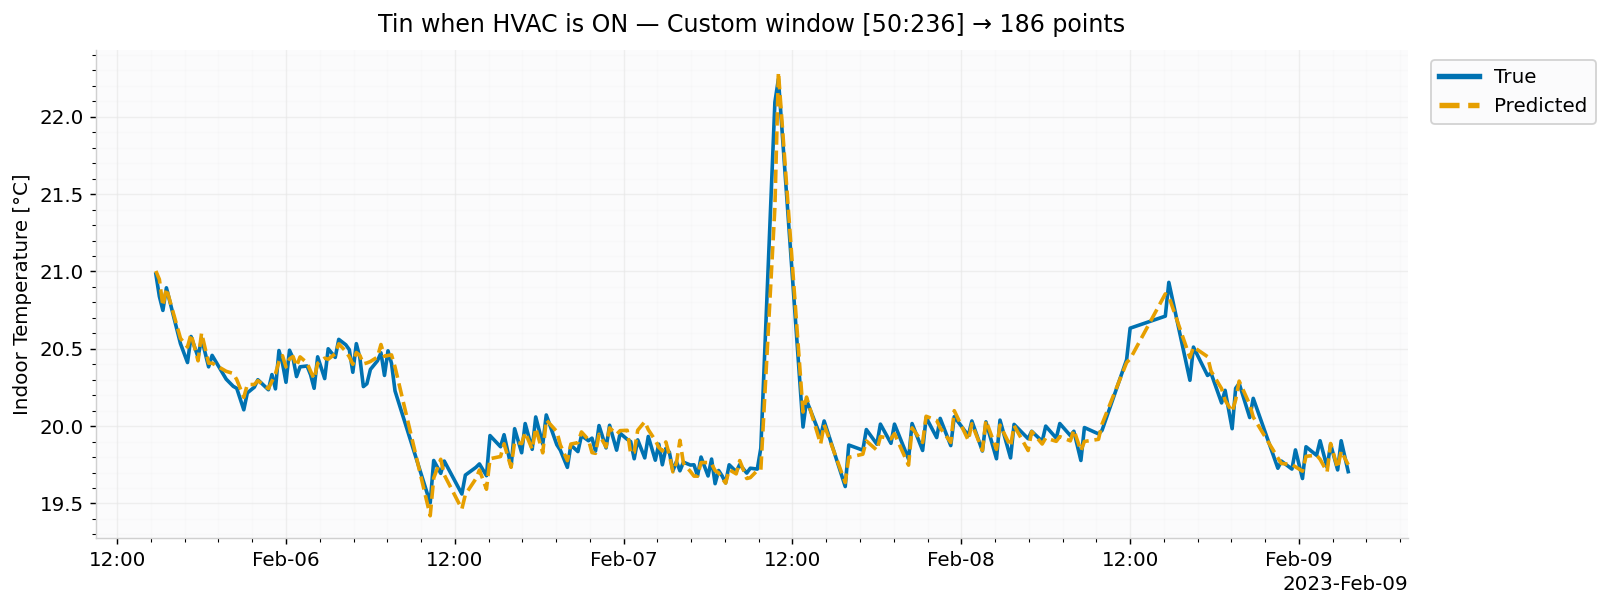

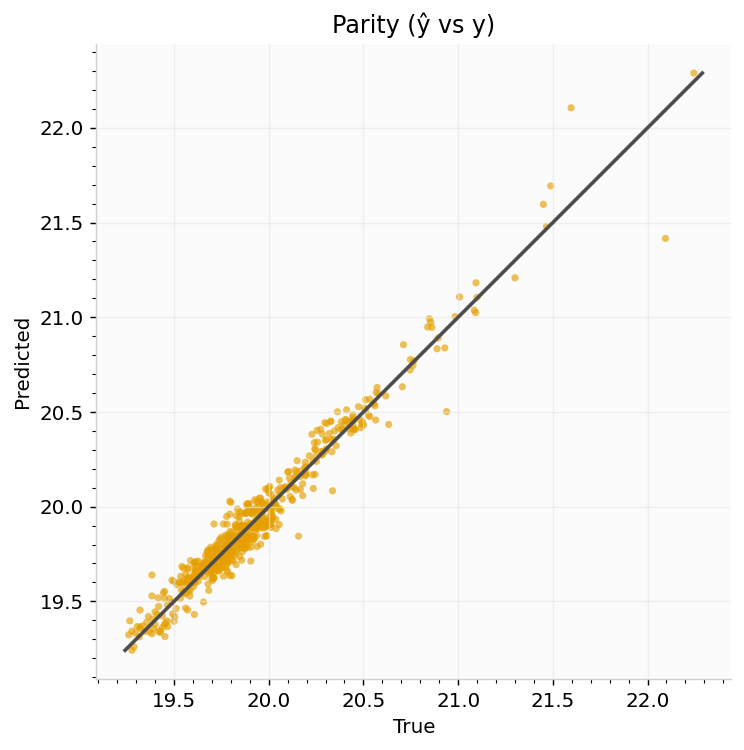

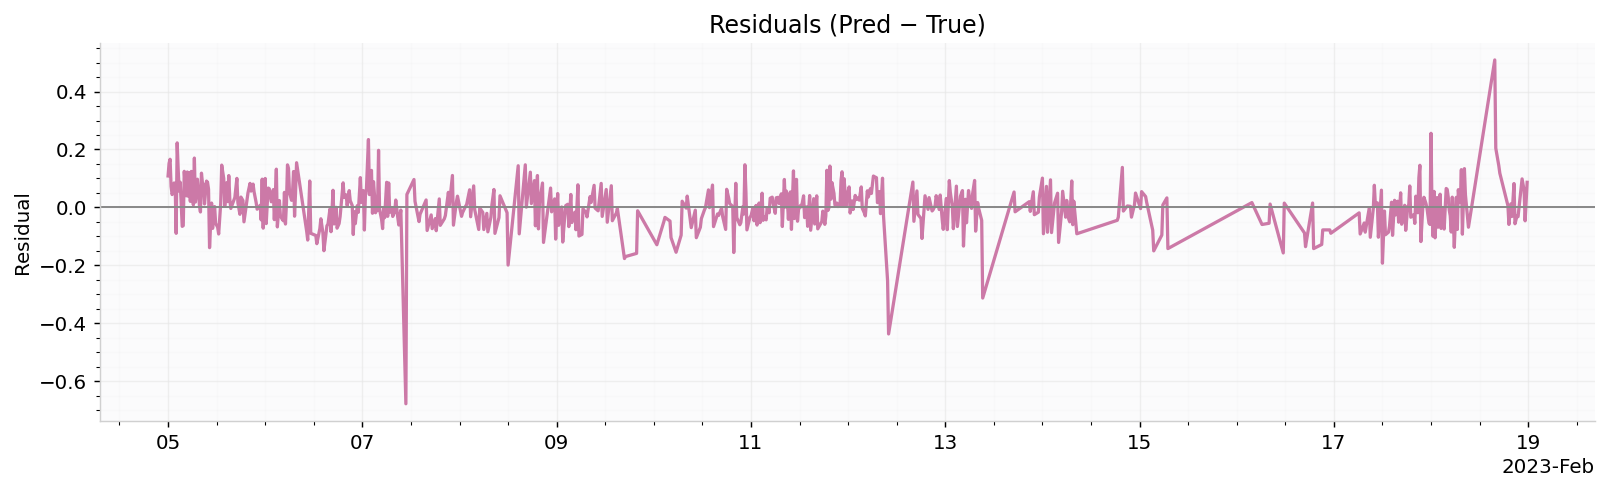

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 160}
Best CV MAE: 0.4719064603476535
[Validation] MAE:   0.089 °C
[Validation] RMSE:  0.117 °C
[Validation] R²:    0.906
[Validation] sMAPE: 0.45 %


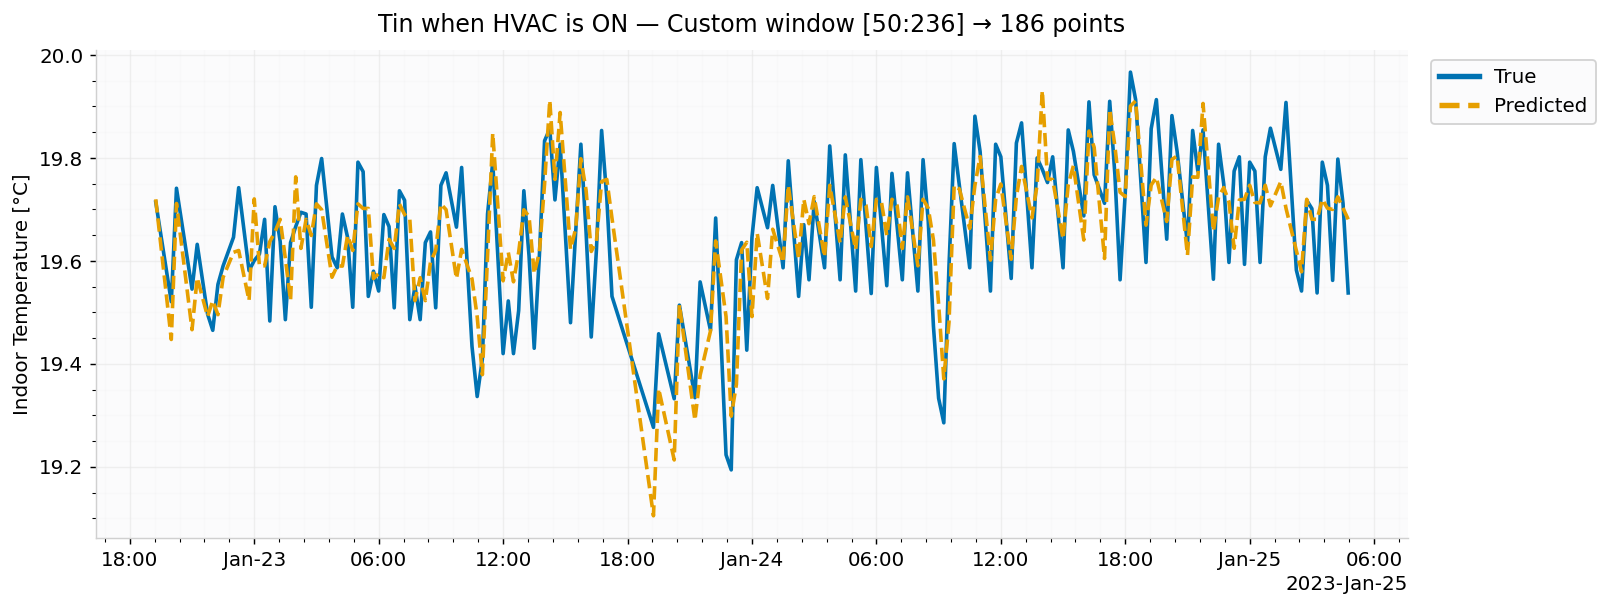

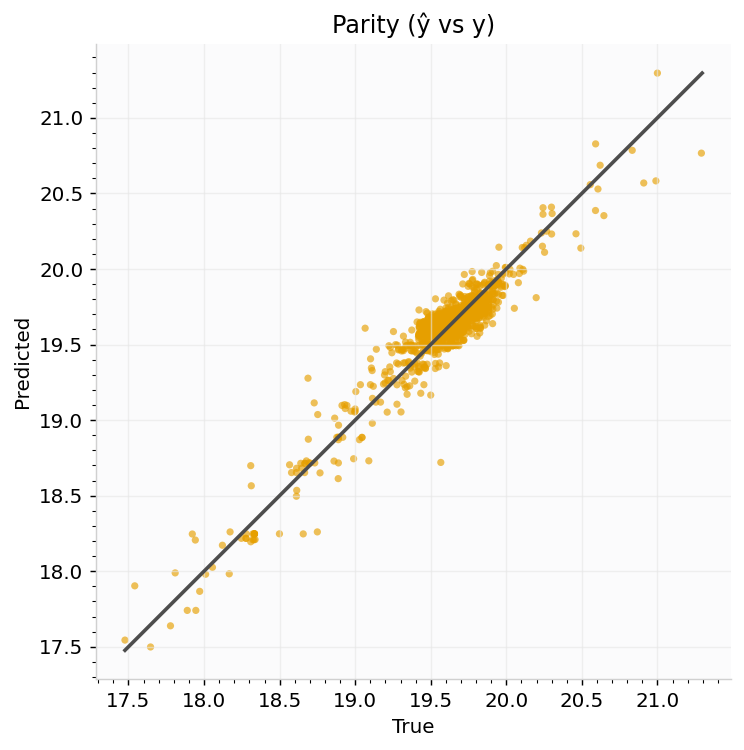

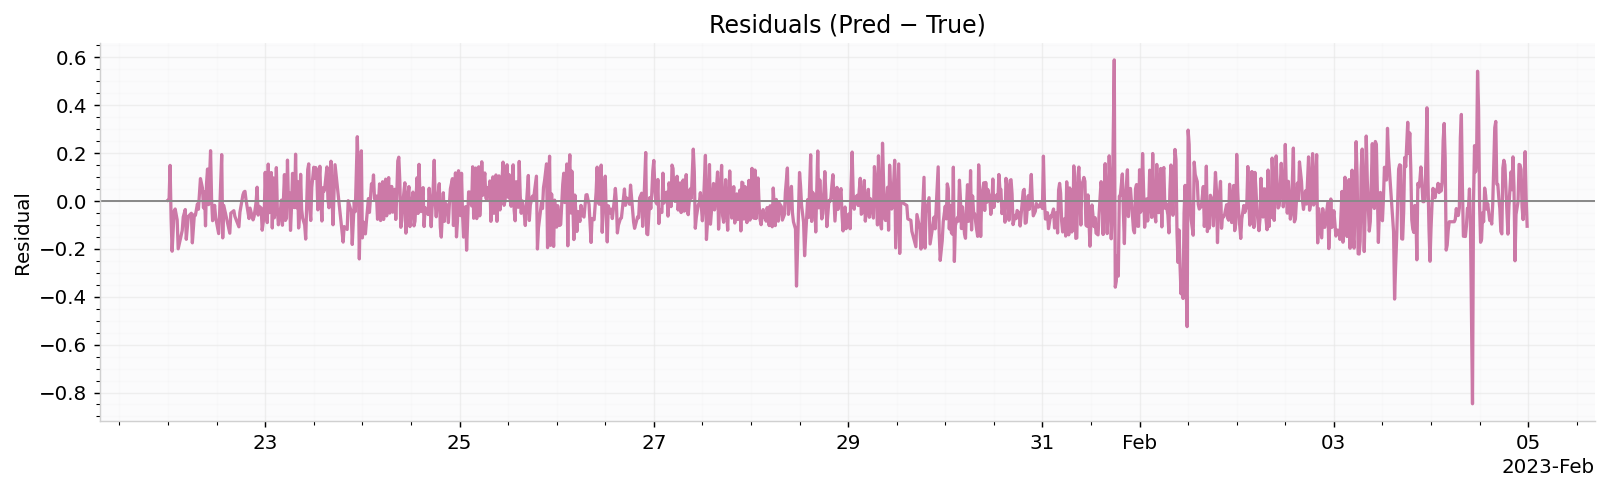

Test MAE: 0.100 °C
Test MAPE: 0.505 %
[df_6] Saved best RF model → models/df_6\best_model_rf.pkl


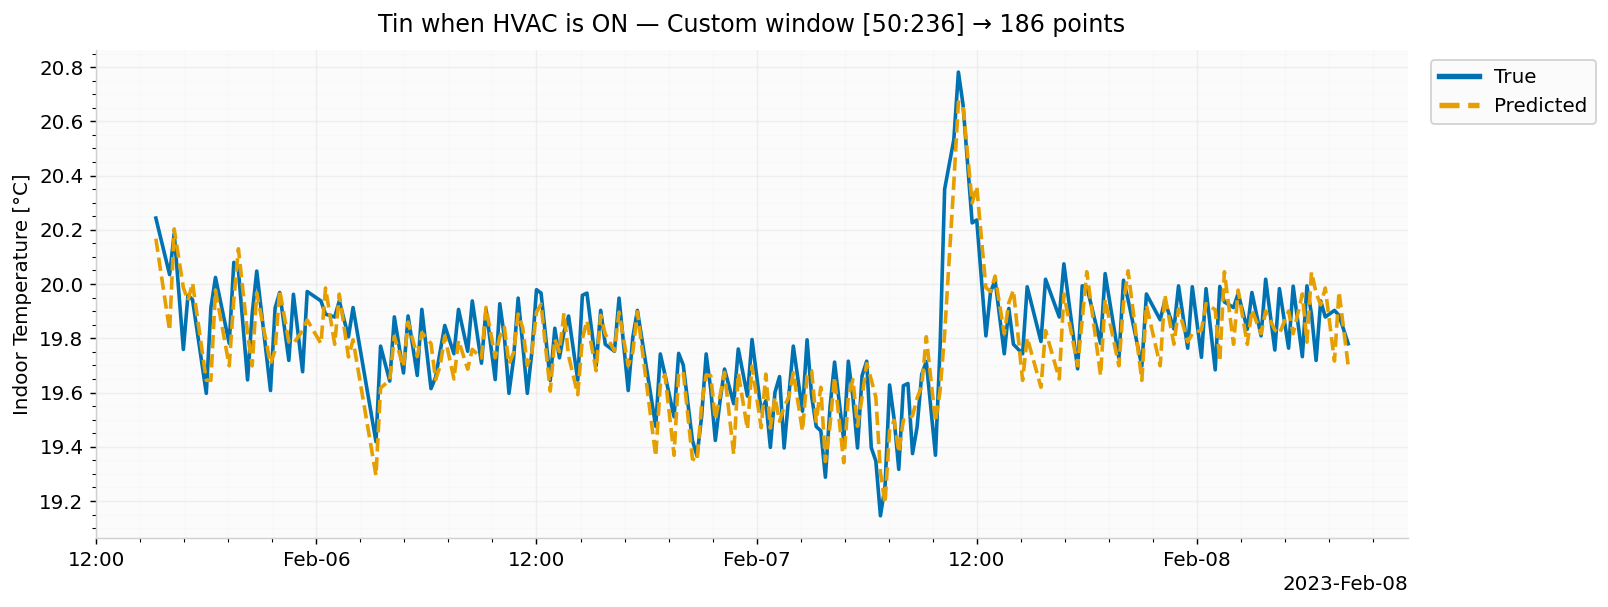

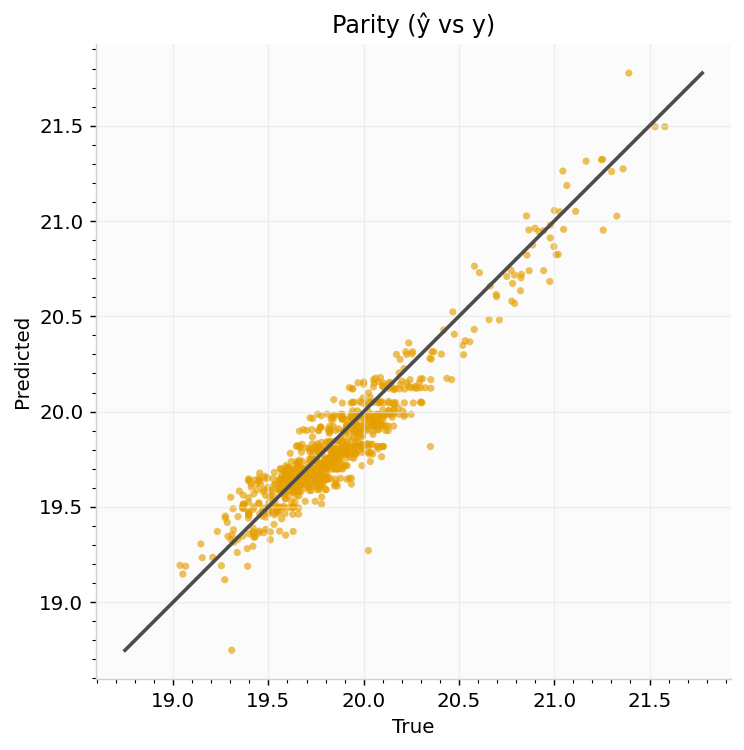

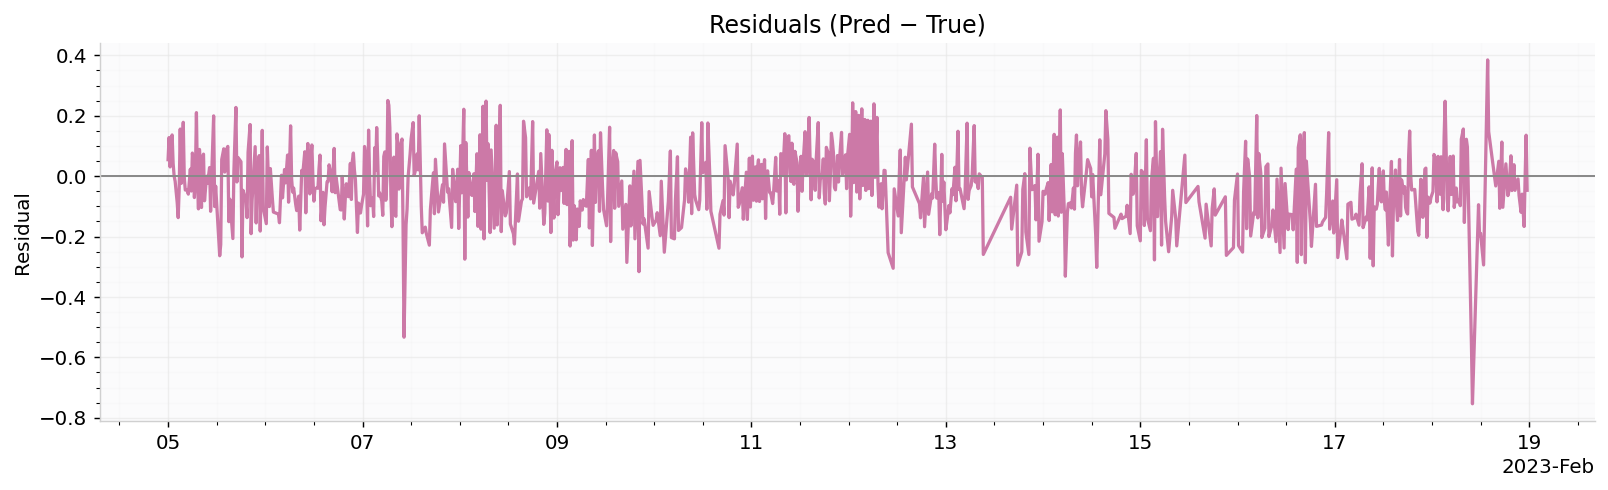

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 8, 'min_samples_leaf': 9, 'min_samples_split': 5, 'n_estimators': 60}
Best CV MAE: 0.15231598082180745
[Validation] MAE:   0.127 °C
[Validation] RMSE:  0.159 °C
[Validation] R²:    0.928
[Validation] sMAPE: 0.67 %


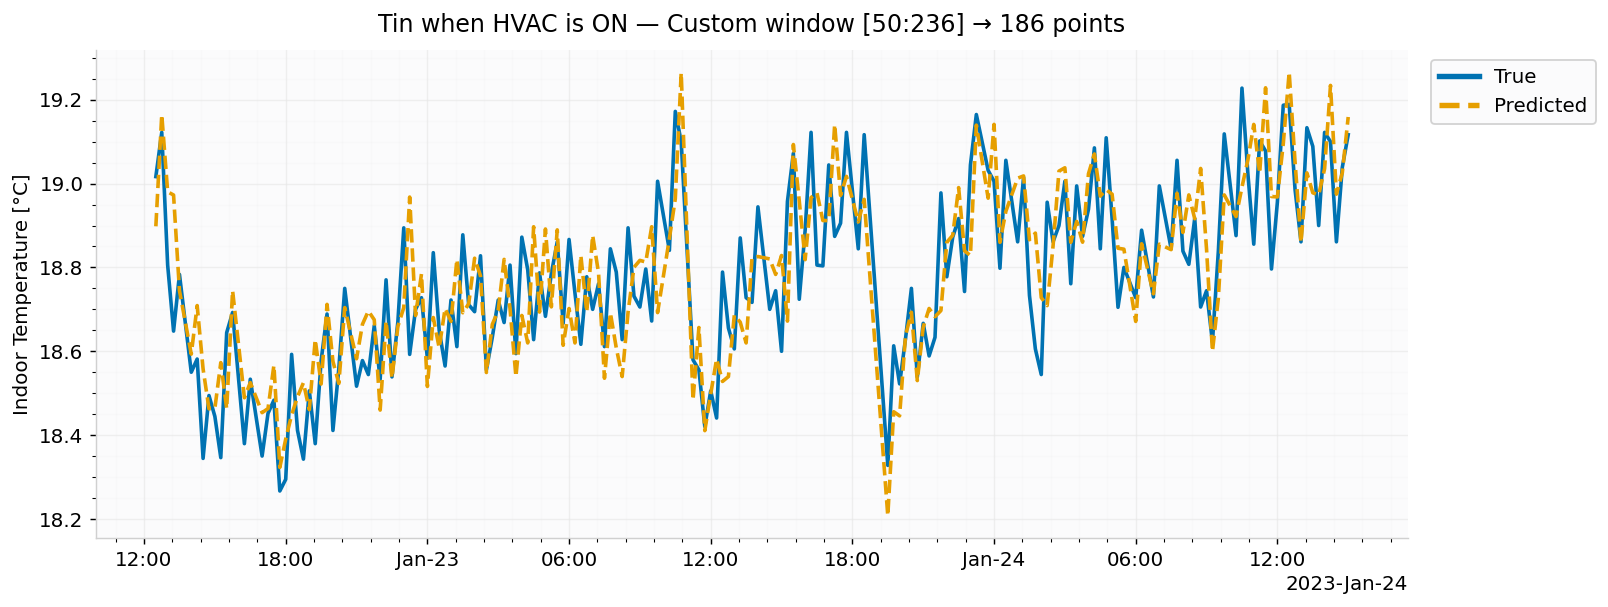

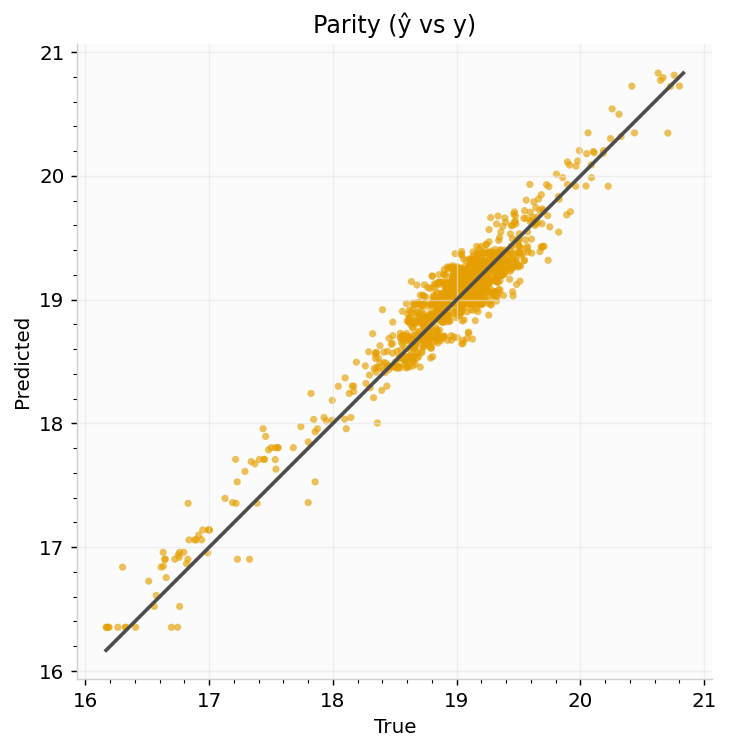

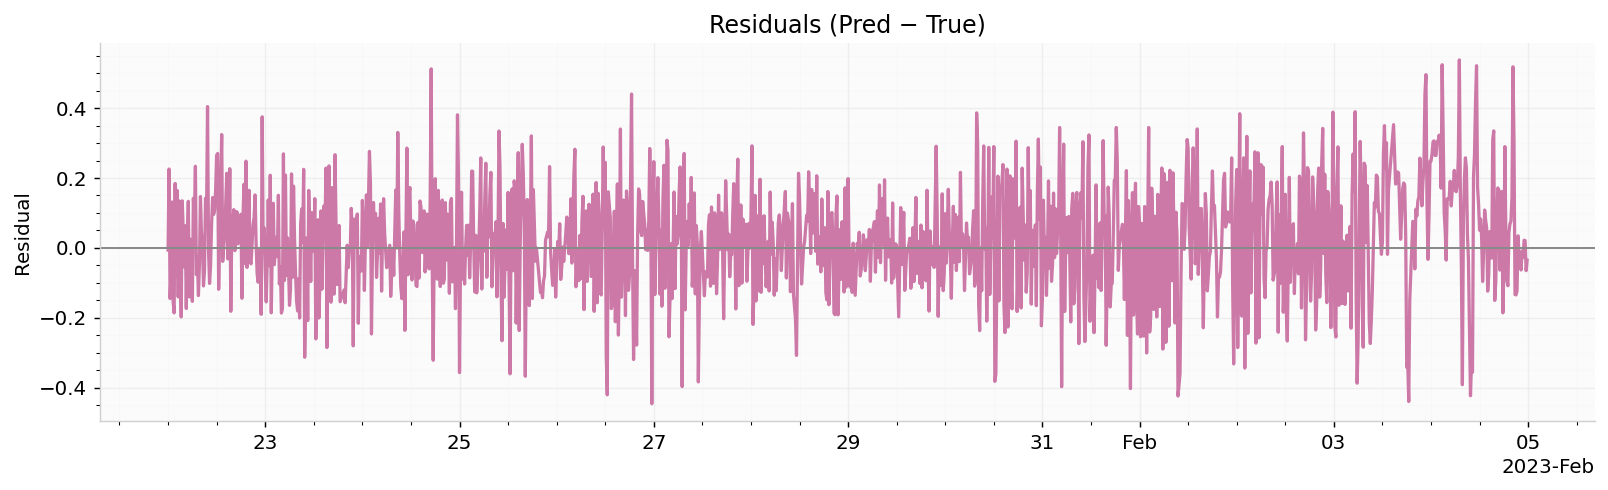

Test MAE: 0.121 °C
Test MAPE: 0.618 %
[df_7] Saved best RF model → models/df_7\best_model_rf.pkl


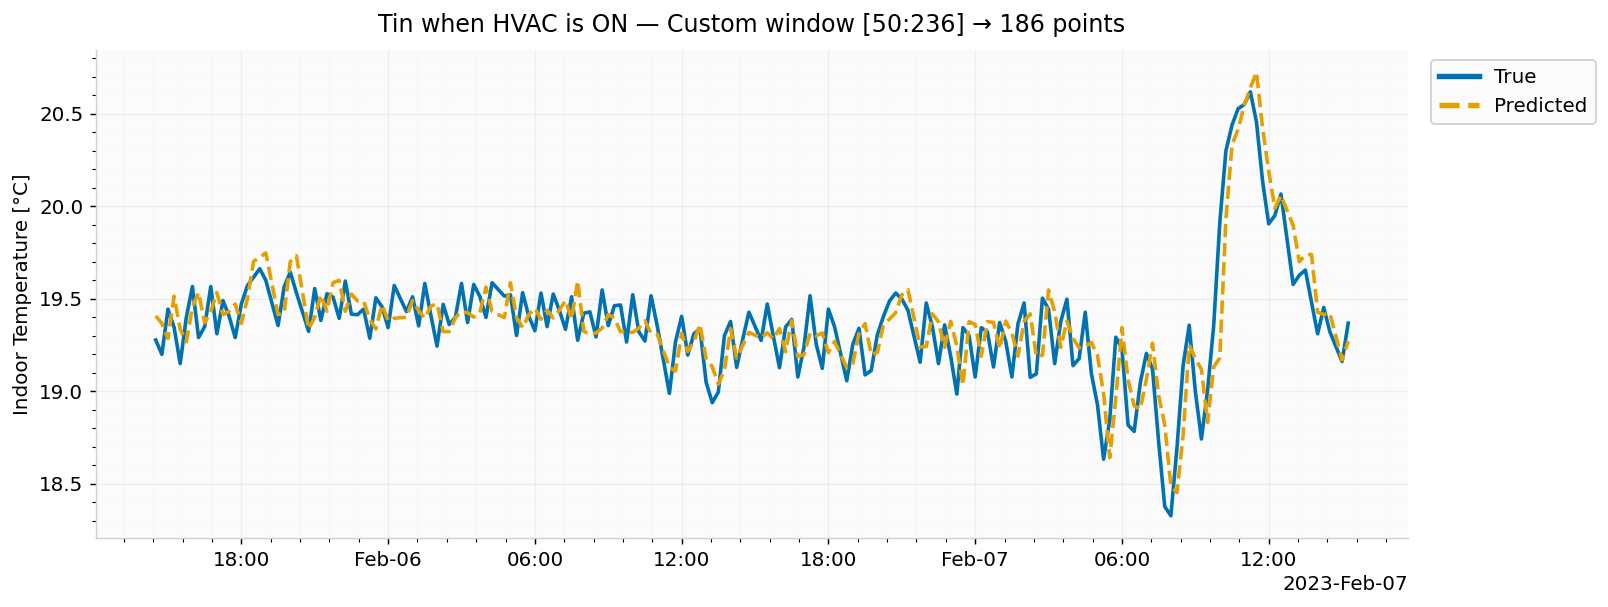

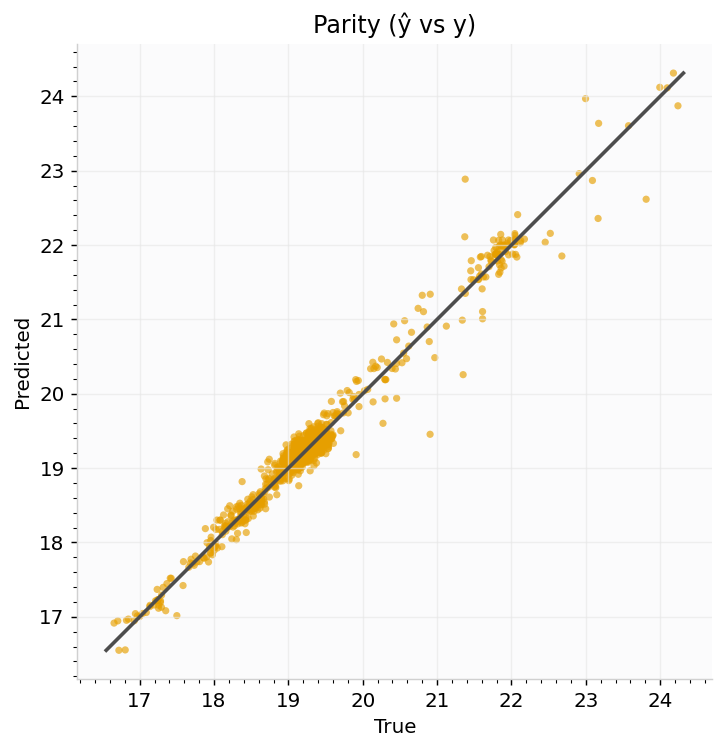

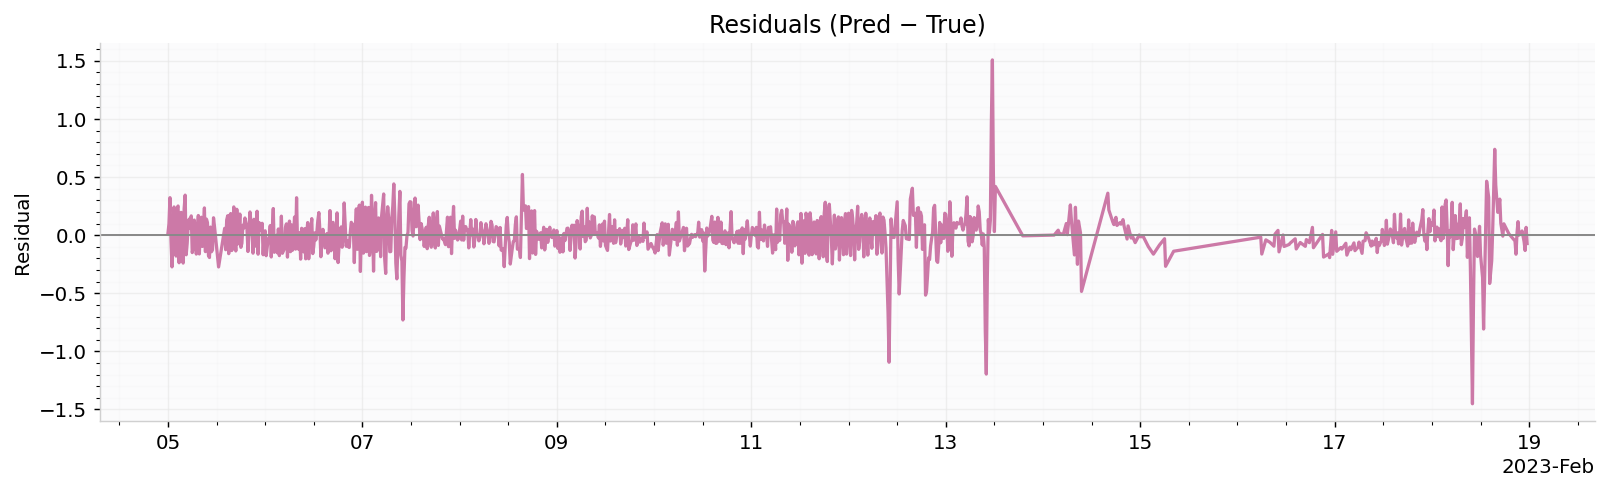

In [6]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from cycler import cycler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100.0

COLORS = {
    "true":   "#0072B2",  # blue
    "pred":   "#E69F00",  # orange
    "resid":  "#CC79A7",  # magenta
    "eqline": "#4D4D4D",  # dark gray
    "zero":   "#8A8A8A",  # mid gray
}

def setup_matplotlib():
    plt.rcParams.update({
        "figure.dpi": 130,
        "figure.facecolor": "white",
        "axes.facecolor": "#FBFBFC",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.alpha": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "legend.edgecolor": "#D0D0D0",
        "font.size": 11,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "lines.linewidth": 2.2,     # a little bolder by default
        "axes.prop_cycle": cycler("color", [COLORS["true"], COLORS["pred"], COLORS["resid"]]),
})
    
def format_time_axis(ax):
    loc = AutoDateLocator()
    fmt = ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.12)

def print_metrics_table(metrics_dict):
    dfm = pd.DataFrame({
        "Metric": ["RMSE", "MAE", "R²", "sMAPE (%)"],
        "Value": [metrics_dict["rmse"], metrics_dict["mae"], metrics_dict["r2"], metrics_dict["smape"]]
    })
    dfm["Value"] = dfm["Value"].map(lambda v: f"{v:,.4f}")
    bar = "="*47
    print("\n" + bar)
    print(" Performance Metrics".center(47, " "))
    print(bar)
    print(dfm.to_string(index=False))
    print(bar + "\n")
    return dfm

def evaluate_and_plot(y_true, y_pred, times, outdir, ylabel="Temperature (°C)", prefix="rf", start_idx=None, end_idx=None, n_skip=6, n_plot=192):
    # os.makedirs(outdir, exist_ok=True)
    setup_matplotlib()

    # --- metrics ---
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    smp  = smape(y_true, y_pred)
    metrics = {"rmse": rmse, "mae": mae, "r2": r2, "smape": smp}

    # print & save metrics
    # metrics_df_print = print_metrics_table(metrics)
    # metrics_df_save  = pd.DataFrame(metrics, index=[0])
    # metrics_df_save.to_csv(os.path.join(outdir, f"{prefix}_metrics.csv"), index=False)

    # results frame
    results = pd.DataFrame({
        "y_true": np.asarray(y_true, dtype=float),
        "y_pred": np.asarray(y_pred, dtype=float)
    }, index=pd.to_datetime(times)).sort_index()
    residuals = results["y_pred"] - results["y_true"]

    # ------------- (1) time-series plot (zoom on a neat window) -------------
    if start_idx is not None and end_idx is not None:
        seg = results.iloc[start_idx:end_idx]
        window_note = f"Custom window [{start_idx}:{end_idx}] → {len(seg)} points"
    else:
        N_plot = min(n_plot, max(0, len(results) - n_skip)) if len(results) > n_skip else len(results)
        seg = results.iloc[n_skip:n_skip + N_plot] if N_plot > 0 else results
        window_note = f"{len(seg)} points (skip {n_skip})"

    fig, ax = plt.subplots(figsize=(12.5, 4.8))
    ax.plot(seg.index, seg["y_true"], linewidth=2.0, label="True", color=COLORS["true"])
    ax.plot(seg.index, seg["y_pred"], linewidth=2.0, linestyle="--", label="Predicted", color=COLORS["pred"])
    ax.set_title(f"Tin when HVAC is ON — {window_note}", pad=10)

    ax.set_ylabel(ylabel)
    format_time_axis(ax)
    leg = ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
    for line in leg.get_lines():
        line.set_linewidth(3)
    fig.tight_layout()
    # fig.savefig(os.path.join(outdir, f"{prefix}_timeseries.png"), bbox_inches="tight")
    plt.show()

    # ------------- (2) parity plot -------------
    fig, ax = plt.subplots(figsize=(5.9, 5.9))
    ax.scatter(results["y_true"], results["y_pred"], s=16, alpha=0.65, edgecolors="none", color=COLORS["pred"])
    mn = float(np.nanmin([results["y_true"].min(), results["y_pred"].min()]))
    mx = float(np.nanmax([results["y_true"].max(), results["y_pred"].max()]))
    ax.plot([mn, mx], [mn, mx], linewidth=2.0, color=COLORS["eqline"])
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title("Parity (ŷ vs y)")
    ax.minorticks_on()
    fig.tight_layout()
    plt.show()

    # ------------- (3) residuals over time -------------
    fig, ax = plt.subplots(figsize=(12.5, 3.9))
    ax.plot(results.index, residuals, linewidth=1.8, color=COLORS["resid"])
    ax.axhline(0.0, linewidth=1.1, color=COLORS["zero"])
    ax.set_title("Residuals (Pred − True)")
    ax.set_ylabel("Residual")
    format_time_axis(ax)
    fig.tight_layout()
    plt.show()

    return metrics


feature_cols = [
    'Tin',        
    'hvac_mode',
    'Tout',
    'T_diff',
]

for index, df in enumerate(dfs):
    df['T_diff'] = (df['Tout'] - df['Tin']).bfill()

    df['Tin_target']  = df['Tin'].shift(-1).dropna()          
    # df['is_test'] = (df.index >= test_start) & (df.index <= test_end)

    train_idx, val_idx, test_idx = make_splits_by_is_test_or_date(df)

    # df_on_train = df_on[~df_on['is_test']]
    # df_on_test = df_on[df_on['is_test']]
    df_train = df.iloc[train_idx]
    df_val   = df.iloc[val_idx]
    df_test  = df.iloc[test_idx]

    # ✅ Only keep HVAC ON for regression
    df_train = df_train[df_train['hvac_mode'] != 0]
    df_val   = df_val[df_val['hvac_mode'] != 0]
    df_test  = df_test[df_test['hvac_mode'] != 0]

    target_col = 'Tin_target'  

    X_train = df_train[feature_cols]
    X_test = df_test[feature_cols]
    y_train = df_train[target_col]
    y_test = df_test[target_col]

    mask = ~y_train.isna()
    X_train = X_train[mask]
    y_train = y_train[mask]

    param_grid = {
        'n_estimators': [60, 80, 100, 120, 160, 200],
        'max_depth': [6, 8, 10, 12, 14],
        'min_samples_leaf': [1, 3, 5, 7, 9],
        'min_samples_split': [2, 5, 10]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)

    grid = GridSearchCV(
        rf,
        param_grid,
        cv=tscv,
        scoring='neg_mean_absolute_error', 
        verbose=2,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    print("Best Params:", grid.best_params_)
    print("Best CV MAE:", -grid.best_score_)

    X_val = df_val[feature_cols]
    y_val = df_val[target_col]

    # Filter NaNs (in case target has any left)
    mask_val = ~y_val.isna()
    X_val = X_val[mask_val]
    y_val = y_val[mask_val]

    y_val_pred = grid.best_estimator_.predict(X_val)

    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_rmse = root_mean_squared_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    val_smape = smape(y_val, y_val_pred)

    print(f"[Validation] MAE:   {val_mae:.3f} °C")
    print(f"[Validation] RMSE:  {val_rmse:.3f} °C")
    print(f"[Validation] R²:    {val_r2:.3f}")
    print(f"[Validation] sMAPE: {val_smape:.2f} %")

    # Save validation metrics
    val_metrics_df = pd.DataFrame({
        "mae": [val_mae],
        "rmse": [val_rmse],
        "r2": [val_r2],
        "smape": [val_smape],
    })
    # val_metrics_df.to_csv(os.path.join(save_dir, "rf_val_metrics.csv"), index=False)

    save_dir = f"models/df_{index}"
    os.makedirs(save_dir, exist_ok=True)
    rf_path = os.path.join(save_dir, 'best_model_rf.pkl')
    evaluate_and_plot(
        y_true=y_val.values,
        y_pred=y_val_pred,
        times=y_val.index,
        outdir=save_dir,
        ylabel="Indoor Temperature [°C]",
        prefix="rf_val",
        start_idx=50,
        end_idx=50 + 186,
    )

    y_true = y_test.values

    y_pred = grid.best_estimator_.predict(X_test)
    mae = np.mean(np.abs(y_pred - y_test))
    mape = np.mean(np.abs((y_pred - y_test) / y_test)) * 100
    print(f"Test MAE: {mae:.3f} °C")
    print(f"Test MAPE: {mape:.3f} %")

    best_model_rf = grid.best_estimator_
    
    joblib.dump(best_model_rf, rf_path)
    start_idx = 50
    end_idx = start_idx + 186 #2 days
    y_true = y_test.values

    y_plot = y_true[start_idx:end_idx]
    y_pred_xg_plot = y_pred[start_idx:end_idx]

    print(f"[df_{index}] Saved best RF model → {rf_path}")

    # evaluate + plots
    ylabel = "Indoor Temperature [°C]"
    metrics = evaluate_and_plot(
        y_true=y_test.values,
        y_pred=y_pred,
        times=y_test.index,          # keep temporal x-axis
        outdir=save_dir,
        ylabel=ylabel,
        prefix="rf_on",
        start_idx=start_idx,
        end_idx=end_idx,
    )
